In [1]:
import pandas as pd
from pathlib import Path


nom_fichier = Path("/home/onyxia/work/data/data_indian_ocean.feather")

df = pd.read_feather(nom_fichier)

df.columns
#


Index(['imo', 'mmsi', 'name', 'latitude', 'longitude', 'timestamp', 'sog',
       'cog', 'nav status', 'nav status code', 'draft', 'time delta (s)',
       'destination', 'information source', 'checked status', 'load type',
       'voyage number', 'origin->destination', 'at port', 'port stay type',
       'wave period Tp (s)', 'significant wave height Hs (m)',
       'mean wave direction (°)', 'sea surface temperature (°K)',
       'air temperature at 2m (°K)', 'eastward wind velocity (m/s)',
       'northward wind velocity (m/s)',
       'mean wave direction relative to vessel (°)'],
      dtype='object')

In [3]:
pip install geodatasets

Note: you may need to restart the kernel to use updated packages.


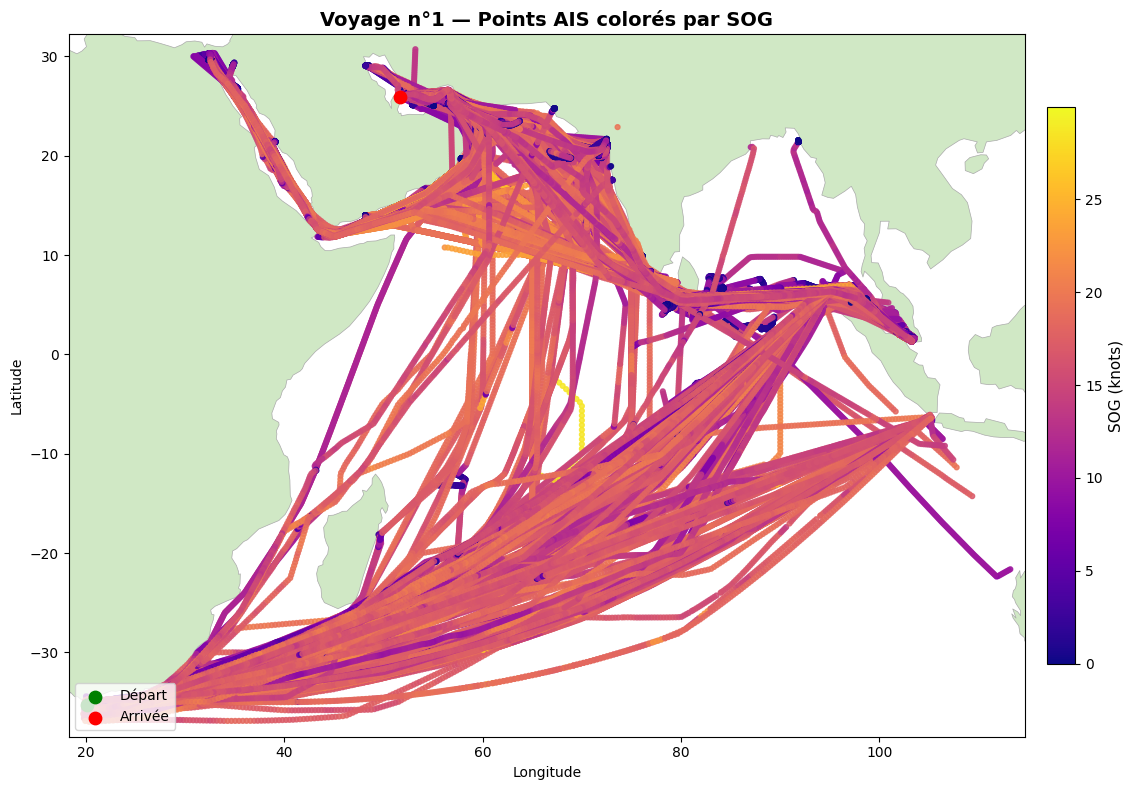

In [2]:
import geopandas as gpd
import geodatasets
import geodatasets
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
from shapely.geometry import Point


def plot_voyage_ais(df: pd.DataFrame, num_voy: int) -> None:
    """
    Affiche les points AIS d'un voyage donné, colorés par SOG.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame contenant au minimum les colonnes :
        - 'longitude'  : float, longitude en degrés décimaux
        - 'latitude'   : float, latitude en degrés décimaux
        - 'sog'        : float, vitesse sur le fond (knots)
        - 'voyage number' : int/str, identifiant du voyage
    num_voy : int
        Numéro du voyage à afficher.

    Returns
    -------
    None — affiche la figure matplotlib.
    """

    # ── 1. Filtrage du voyage ──────────────────────────────────────────────────
    df_voy = df[df["voyage number"] == num_voy].copy()

    if df_voy.empty:
        raise ValueError(f"Aucun point trouvé pour le voyage num_voy={num_voy}.")

    # ── 2. Création du GeoDataFrame ───────────────────────────────────────────
    geometry = [Point(lon, lat) for lon, lat in zip(df_voy["longitude"], df_voy["latitude"])]
    gdf = gpd.GeoDataFrame(df_voy, geometry=geometry, crs="EPSG:4326")

    # ── 3. Fond de carte (Natural Earth via geodatasets) ─────────────────────
    world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

    # Calcul du bounding box avec marge
    margin = 1.5  # degrés
    lon_min, lat_min = gdf["longitude"].min() - margin, gdf["latitude"].min() - margin
    lon_max, lat_max = gdf["longitude"].max() + margin, gdf["latitude"].max() + margin

    world_crop = world.cx[lon_min:lon_max, lat_min:lat_max]

    # ── 4. Colormap SOG ───────────────────────────────────────────────────────
    sog_min, sog_max = gdf["sog"].min(), gdf["sog"].max()
    norm = mcolors.Normalize(vmin=sog_min, vmax=sog_max)
    cmap = cm.plasma

    # ── 5. Figure ─────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 8))

    # Fond de carte
    world_crop.plot(ax=ax, color="#d0e8c5", edgecolor="#aaaaaa", linewidth=0.5)

    # Points AIS colorés par SOG
    gdf.plot(
        ax=ax,
        column="sog",
        cmap=cmap,
        norm=norm,
        markersize=12,
        alpha=0.85,
        legend=False,
    )

    # Colorbar manuelle
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("SOG (knots)", fontsize=11)

    # Premier et dernier point mis en évidence
    first, last = gdf.iloc[0], gdf.iloc[-1]
    ax.scatter(first.geometry.x, first.geometry.y,
               color="green", s=80, zorder=5, label="Départ")
    ax.scatter(last.geometry.x, last.geometry.y,
               color="red", s=80, zorder=5, label="Arrivée")

    # ── 6. Habillage ──────────────────────────────────────────────────────────
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_title(f"Voyage n°{num_voy} — Points AIS colorés par SOG", fontsize=14, fontweight="bold")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(loc="lower left", fontsize=10)

    plt.tight_layout()
    plt.show()



plot_voyage_ais(df, num_voy=1)

In [3]:
def intervalles_voyages(df, num_voy):
    """
    Retourne la liste des intervalles où la SOG est > 2 noeuds.
    Travaille directement sur le DataFrame AIS brut.

    OUTPUT :
        liste de tuples (timestamp_debut, timestamp_fin)
    """

    df_voyage = df[df["voyage number"] == num_voy].copy()
    df_voyage = df_voyage.sort_values("timestamp").reset_index(drop=True)
    df_voyage["timestamp"] = pd.to_datetime(df_voyage["timestamp"])

    intervalles = []
    debut = None

    for idx, row in df_voyage.iterrows():
        if row["sog"] > 1:
            if debut is None:
                debut = row["timestamp"]
            fin = row["timestamp"]
        else:
            if debut is not None:
                intervalles.append((debut, fin))
                debut = None

    if debut is not None:
        intervalles.append((debut, fin))

    return intervalles
    

In [4]:
def plot_ais_intervalle(df: pd.DataFrame, ts_debut, ts_fin) -> None:
    """
    Affiche les points AIS entre deux timestamps, colorés par SOG.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame contenant au minimum les colonnes :
        - 'longitude'  : float, longitude en degrés décimaux
        - 'latitude'   : float, latitude en degrés décimaux
        - 'sog'        : float, vitesse sur le fond (knots)
        - 'timestamp'  : datetime
    ts_debut : timestamp de début
    ts_fin   : timestamp de fin

    Returns
    -------
    None — affiche la figure matplotlib.
    """

    # ── 1. Filtrage par intervalle ─────────────────────────────────────────────
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    ts_debut = pd.to_datetime(ts_debut)
    ts_fin   = pd.to_datetime(ts_fin)

    df_voy = df[(df["timestamp"] >= ts_debut) & (df["timestamp"] <= ts_fin)].copy()

    if df_voy.empty:
        raise ValueError(f"Aucun point trouvé entre {ts_debut} et {ts_fin}.")

    # ── 2. Création du GeoDataFrame ───────────────────────────────────────────
    geometry = [Point(lon, lat) for lon, lat in zip(df_voy["longitude"], df_voy["latitude"])]
    gdf = gpd.GeoDataFrame(df_voy, geometry=geometry, crs="EPSG:4326")

    # ── 3. Fond de carte ──────────────────────────────────────────────────────
    world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

    margin = 1.5
    lon_min = gdf["longitude"].min() - margin
    lat_min = gdf["latitude"].min() - margin
    lon_max = gdf["longitude"].max() + margin
    lat_max = gdf["latitude"].max() + margin

    world_crop = world.cx[lon_min:lon_max, lat_min:lat_max]

    # ── 4. Colormap SOG ───────────────────────────────────────────────────────
    sog_min, sog_max = gdf["sog"].min(), gdf["sog"].max()
    norm = mcolors.Normalize(vmin=sog_min, vmax=sog_max)
    cmap = cm.plasma

    # ── 5. Figure ─────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 8))

    world_crop.plot(ax=ax, color="#d0e8c5", edgecolor="#aaaaaa", linewidth=0.5)

    gdf.plot(ax=ax, column="sog", cmap=cmap, norm=norm,
             markersize=12, alpha=0.85, legend=False)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("SOG (knots)", fontsize=11)

    first, last = gdf.iloc[0], gdf.iloc[-1]
    ax.scatter(first.geometry.x, first.geometry.y,
               color="green", s=80, zorder=5, label="Début")
    ax.scatter(last.geometry.x, last.geometry.y,
               color="red", s=80, zorder=5, label="Fin")

    # ── 6. Habillage ──────────────────────────────────────────────────────────
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_title(f"Points AIS du {ts_debut} au {ts_fin}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(loc="lower left", fontsize=10)

    plt.tight_layout()
    plt.show()

In [5]:
def plot_sog_intervalle(df: pd.DataFrame, ts_debut, ts_fin) -> None:
    """
    Affiche la SOG en fonction du temps entre deux timestamps.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame contenant 'timestamp' et 'sog'
    ts_debut : timestamp de début
    ts_fin   : timestamp de fin
    """

    df["timestamp"] = pd.to_datetime(df["timestamp"])
    ts_debut = pd.to_datetime(ts_debut)
    ts_fin   = pd.to_datetime(ts_fin)

    df_filtre = df[(df["timestamp"] >= ts_debut) & (df["timestamp"] <= ts_fin)].copy()
    df_filtre = df_filtre.sort_values("timestamp")

    if df_filtre.empty:
        raise ValueError(f"Aucun point trouvé entre {ts_debut} et {ts_fin}.")

    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(df_filtre["timestamp"], df_filtre["sog"], color="steelblue", linewidth=1.2)
    ax.fill_between(df_filtre["timestamp"], df_filtre["sog"], alpha=0.2, color="steelblue")

    ax.set_title(f"SOG du {ts_debut} au {ts_fin}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("SOG (knots)")
    ax.axhline(y=1, color="red", linestyle="--", linewidth=0.8, label="Seuil 1 nœud")
    ax.legend()

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [6]:
import numpy as np

def decouper_intervalles(df: pd.DataFrame, seuil_sog: float = 1.0) -> pd.DataFrame:

    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp").reset_index(drop=True)

    # ── 1. Identifier les intervalles via les ruptures de SOG ─────────────────
    en_mouvement = df["sog"] > seuil_sog
    changement   = en_mouvement != en_mouvement.shift()
    df["id_intervalle"] = changement[en_mouvement].cumsum()
    df.loc[~en_mouvement, "id_intervalle"] = pd.NA

    # ── 2. Enrichissement vectorisé par intervalle ────────────────────────────
    def enrichir(groupe):

        lats = groupe["latitude"].values
        lons = groupe["longitude"].values
        ts   = groupe["timestamp"].values

        # Départ / arrivée
        groupe["coord_depart"]  = [(lats[0], lons[0])] * len(groupe)
        groupe["coord_arrivee"] = [(lats[-1], lons[-1])] * len(groupe)

        # Durée
        duree = (ts[-1] - ts[0]) / pd.Timedelta(hours=1)
        groupe["duree_h"] = duree

        # Distance cumulée vectorisée
        dlat = np.diff(lats)
        dlon = np.diff(lons)
        d_segments = np.sqrt(dlat**2 + dlon**2)  # approx. euclidienne
        dist_cum   = np.concatenate([[0], np.cumsum(d_segments)])
        dist_tot   = dist_cum[-1]

        groupe["avancee_pct"] = (dist_cum / dist_tot * 100) if dist_tot > 0 else 0.0

        return groupe

    df = df.groupby("id_intervalle", group_keys=False).apply(enrichir)

    return df

In [7]:
navires_sample = pd.Series(df["mmsi"].unique()).sample(n=7, random_state=42)
df_sample = df[df["mmsi"].isin(navires_sample)].copy()

print(f"Taille du sample : {len(df_sample):,} lignes")
print(f"Navires : {df_sample['mmsi'].nunique()}")

Taille du sample : 49,051 lignes
Navires : 7


In [8]:
df_enrichi = decouper_intervalles(df_sample, seuil_sog=1.0)

df_enrichi.head()

/tmp/ipykernel_527776/1185772739.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("id_intervalle", group_keys=False).apply(enrichir)


,imo,mmsi,name,latitude,longitude,timestamp,sog,cog,nav status,nav status code,...,sea surface temperature (°K),air temperature at 2m (°K),eastward wind velocity (m/s),northward wind velocity (m/s),mean wave direction relative to vessel (°),id_intervalle,coord_depart,coord_arrivee,duree_h,avancee_pct
0,9390185,563290000,STX FRONTIER,-36.897613,19.935643,2012-02-01 06:05:31,20.341705,112.188719,Under Way Using Engine,0,...,295.330953,292.543191,7.793829,4.164668,109.966924,1.0,"(-36.89761324852398, 19.935643453143477)","(9.875953251749921, 75.94575890787958)",27801.158611,0.000000
1,9390185,563290000,STX FRONTIER,-36.985743,20.327175,2012-02-01 07:05:31,19.931506,85.000000,Under Way Using Engine,0,...,295.532194,292.289957,6.568852,6.244398,136.958888,1.0,"(-36.89761324852398, 19.935643453143477)","(9.875953251749921, 75.94575890787958)",27801.158611,0.305912
2,9390185,563290000,STX FRONTIER,-36.962154,20.742833,2012-02-01 08:05:31,20.286396,85.000000,Under Way Using Engine,0,...,295.792493,292.300459,5.435453,7.422201,136.517462,1.0,"(-36.89761324852398, 19.935643453143477)","(9.875953251749921, 75.94575890787958)",27801.158611,0.623257
3,9390185,563290000,STX FRONTIER,-36.939202,21.168344,2012-02-01 09:05:31,19.820034,86.599888,Under Way Using Engine,0,...,296.037106,292.502778,4.523942,7.913214,137.191493,1.0,"(-36.89761324852398, 19.935643453143477)","(9.875953251749921, 75.94575890787958)",27801.158611,0.948074
4,9390185,563290000,STX FRONTIER,-36.918118,21.583380,2012-02-01 10:05:31,19.313410,86.440230,Under Way Using Engine,0,...,296.564812,292.760062,4.287472,7.755868,134.539471,1.0,"(-36.89761324852398, 19.935643453143477)","(9.875953251749921, 75.94575890787958)",27801.158611,1.264844


In [11]:
df_enrichi.columns

Index(['imo', 'mmsi', 'name', 'latitude', 'longitude', 'timestamp', 'sog',
       'cog', 'nav status', 'nav status code', 'draft', 'time delta (s)',
       'destination', 'information source', 'checked status', 'load type',
       'voyage number', 'origin->destination', 'at port', 'port stay type',
       'wave period Tp (s)', 'significant wave height Hs (m)',
       'mean wave direction (°)', 'sea surface temperature (°K)',
       'air temperature at 2m (°K)', 'eastward wind velocity (m/s)',
       'northward wind velocity (m/s)',
       'mean wave direction relative to vessel (°)', 'id_intervalle',
       'coord_depart', 'coord_arrivee', 'duree_h', 'avancee_pct'],
      dtype='object')

In [12]:
def summary(df):
    stats = df.describe(include="all").T
    stats["dtype"]    = df.dtypes
    stats["n_missing"] = df.isna().sum()
    stats["pct_missing"] = (df.isna().mean() * 100).round(2)
    return stats

summary(df_enrichi)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std,dtype,n_missing,pct_missing
imo,36553.0,NaN,NaN,NaN,9703322.005772,9390185.0,9635315.0,9635315.0,9721724.0,9958664.0,108279.537273,int64,0,0.00
mmsi,36553.0,NaN,NaN,NaN,421760186.678248,224444000.0,228415700.0,538004981.0,538004981.0,563290000.0,149127867.16332,int64,0,0.00
name,36553,8,GOLAR SNOW,18055,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,0,0.00
latitude,36553.0,NaN,NaN,NaN,1.965265,-39.346474,-14.504402,6.159954,17.489022,30.313112,19.472572,float64,0,0.00
longitude,36553.0,NaN,NaN,NaN,59.543462,19.857507,43.528704,58.266501,72.24966,109.112764,19.980855,float64,0,0.00
timestamp,36553,NaN,NaN,NaN,2020-05-26 12:59:59.716576512,2012-02-01 06:05:31,2018-01-13 08:15:02,2020-05-13 15:15:02,2023-01-09 19:15:02,2025-01-04 10:02:06,NaN,datetime64[ns],0,0.00
sog,36553.0,NaN,NaN,NaN,14.853453,1.00813,13.0,15.571154,17.6,23.078983,3.678549,float64,0,0.00
cog,36553.0,NaN,NaN,NaN,177.249937,0.0,76.916821,186.981188,256.034043,359.99084,99.455986,float64,0,0.00
nav status,36547,8,Under Way Using Engine,36373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,6,0.02
nav status code,36553.0,NaN,NaN,NaN,0.009986,0.0,0.0,0.0,0.0,8.0,0.185765,int64,0,0.00


In [13]:
from shapely.geometry import Point
import geodatasets

def distance_cote(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ajoute une colonne 'dist_cote_km' à chaque point AIS.
    """
    df = df.copy()

    # Fond de carte côtier
    world = gpd.read_file(geodatasets.get_path("naturalearth.land"))
    cotes = world.union_all()  # un seul polygone fusionné

    # GeoDataFrame des points AIS
    geometry = [Point(lon, lat) for lon, lat in zip(df["longitude"], df["latitude"])]
    gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

    # Distance en degrés → conversion en km (1 degré ≈ 111 km)
    gdf["dist_cote_km"] = gdf.geometry.distance(cotes) * 111

    return gdf.drop(columns="geometry")

df_enrichi=distance_cote(df_enrichi)

/tmp/ipykernel_527414/398186044.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["dist_cote_km"] = gdf.geometry.distance(cotes) * 111


In [14]:
import matplotlib.pyplot as plt

def scatter_plot(df, x_col, y_col, color_col=None, size_col=None,
                 title=None, xlabel=None, ylabel=None, figsize=(8,6), alpha=0.7):
    """
    Affiche un scatter plot pour deux variables.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame contenant les colonnes à tracer
    x_col : str
        Nom de la colonne pour l'axe X
    y_col : str
        Nom de la colonne pour l'axe Y
    color_col : str, optional
        Colonne pour la couleur des points
    size_col : str, optional
        Colonne pour la taille des points
    title : str, optional
        Titre du graphique
    xlabel : str, optional
        Label axe X
    ylabel : str, optional
        Label axe Y
    figsize : tuple, optional
        Taille de la figure (largeur, hauteur)
    alpha : float, optional
        Transparence des points (0 à 1)
    """

    plt.figure(figsize=figsize)

    if color_col and size_col:
        sc = plt.scatter(df[x_col], df[y_col], c=df[color_col], s=df[size_col],
                         alpha=alpha, cmap='viridis')
    elif color_col:
        sc = plt.scatter(df[x_col], df[y_col], c=df[color_col], alpha=alpha, cmap='viridis')
        plt.colorbar(sc, label=color_col)
    elif size_col:
        sc = plt.scatter(df[x_col], df[y_col], s=df[size_col], alpha=alpha)
    else:
        sc = plt.scatter(df[x_col], df[y_col], alpha=alpha)

    plt.xlabel(xlabel if xlabel else x_col)
    plt.ylabel(ylabel if ylabel else y_col)
    if title:
        plt.title(title)

    plt.grid(True)
    plt.show()

In [15]:
Vargood=['wave period Tp (s)', 'significant wave height Hs (m)',
       'mean wave direction (°)', 'sea surface temperature (°K)',
       'air temperature at 2m (°K)', 'eastward wind velocity (m/s)',
       'northward wind velocity (m/s)',
       'mean wave direction relative to vessel (°)','dist_cote_km']

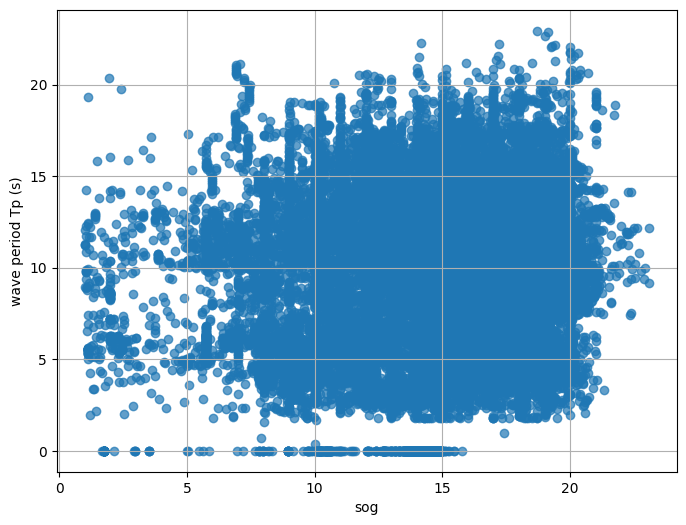

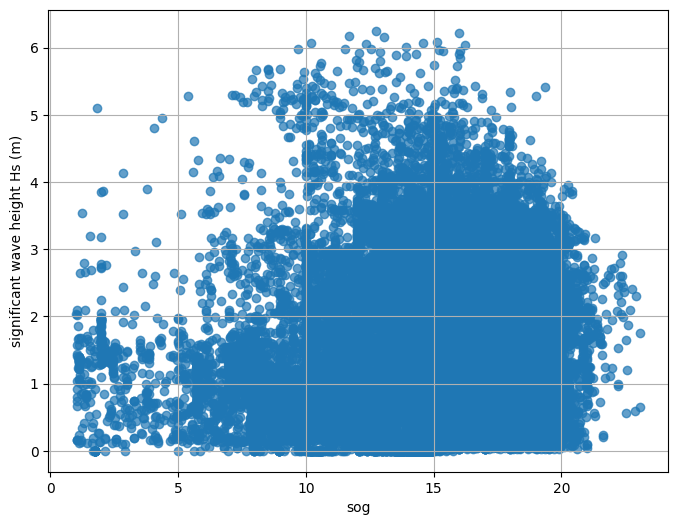

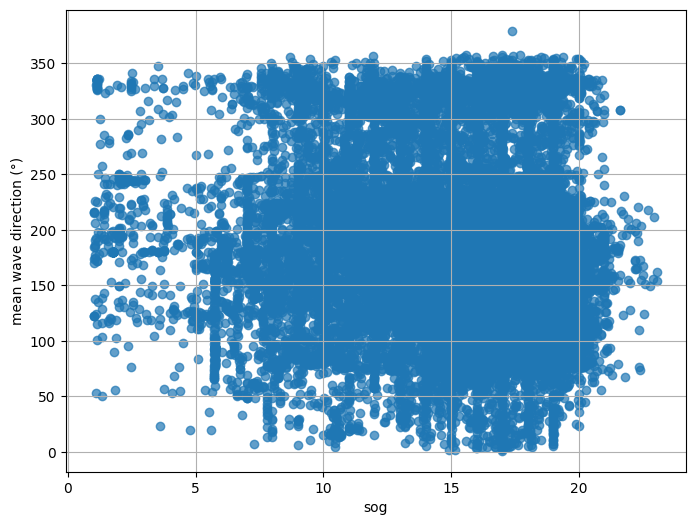

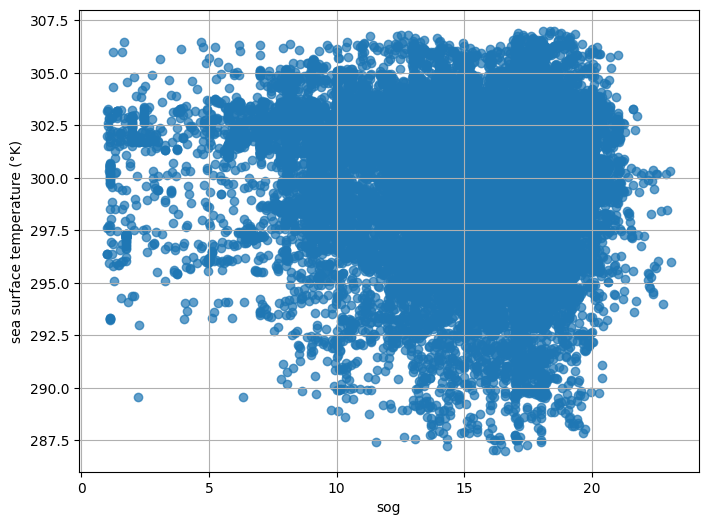

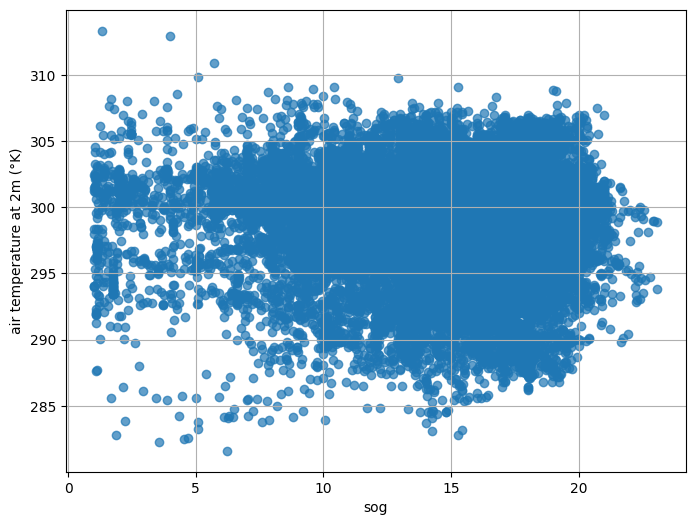

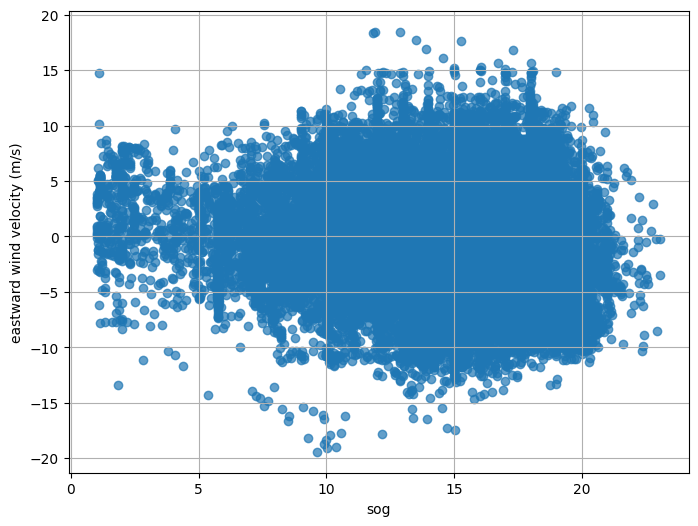

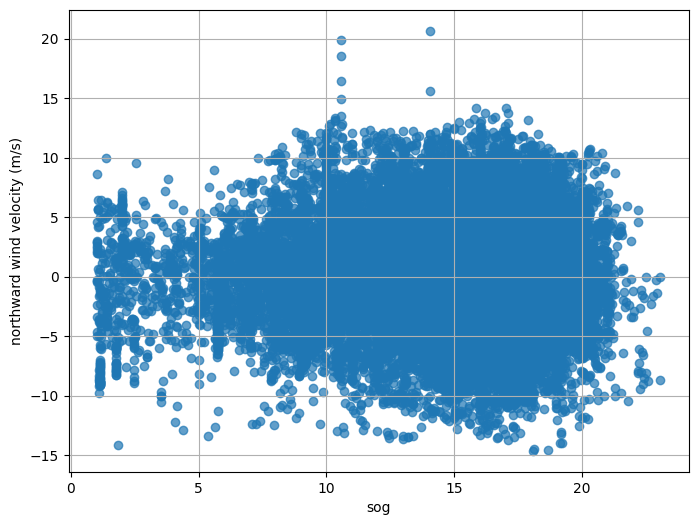

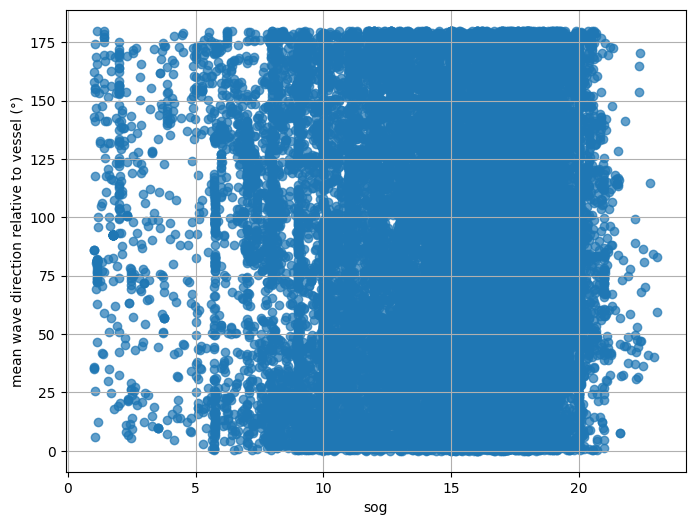

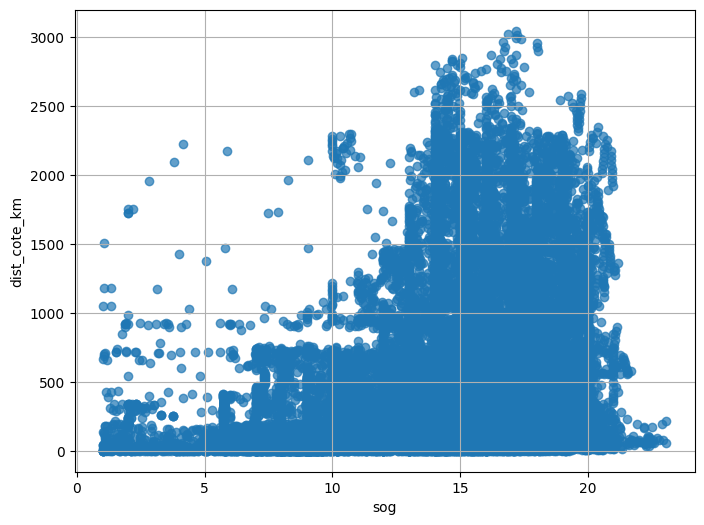

In [16]:
for second_variable in Vargood:
        scatter_plot(df_enrichi, x_col='sog', y_col=second_variable,
                         color_col=None, size_col=None,
                                          title=None, xlabel=None, ylabel=None, figsize=(8,6), alpha=0.7)

Utilisation de la bibliothèque searoute : https://pypi.org/project/searoute/

In [17]:
def nettoyer_delta_sog(df_serie: pd.DataFrame, seuil: float = 3.0) -> pd.DataFrame:
    """
    Exclut les valeurs aberrantes de delta_sog (> seuil en noeuds)
    et convertit delta_sog en m/s.

    1 noeud = 0.514444 m/s

    Parameters
    ----------
    df_serie : DataFrame issu de construire_serie_normalisee()
    seuil    : seuil en noeuds au-delà duquel on exclut (défaut : 3)

    Returns
    -------
    DataFrame nettoyé avec delta_sog en m/s
    """

    KNOTS_TO_MS = 0.514444

    df_clean = df_serie.copy()

    # ── 1. Exclusion des valeurs aberrantes ───────────────────────────────────
    n_avant = len(df_clean)
    df_clean = df_clean[df_clean["delta_sog"].abs() <= seuil]
    n_apres  = len(df_clean)

    print(f"Points exclus : {n_avant - n_apres:,} ({(n_avant - n_apres) / n_avant * 100:.2f}%)")

    # ── 2. Conversion en m/s ──────────────────────────────────────────────────
    df_clean["delta_sog"] = df_clean["delta_sog"] * KNOTS_TO_MS

    print(f"Delta SOG converti en m/s — plage : [{df_clean['delta_sog'].min():.3f}, {df_clean['delta_sog'].max():.3f}] m/s")

    return df_clean

In [18]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

def construire_serie_normalisee(
    df_enrichi: pd.DataFrame,
    n_points: int = 100,
    cols_exogenes: list = ["dist_cote_km", "wind_speed"]  # adapter selon tes colonnes météo
) -> pd.DataFrame:
    """
    Construit une série temporelle normalisée du Delta SOG
    sur une grille d'avancement 0% → 100% pour chaque intervalle.

    Parameters
    ----------
    df_enrichi    : DataFrame enrichi par decouper_intervalles()
    n_points      : nombre de points sur la grille normalisée (défaut 100)
    cols_exogenes : colonnes exogènes à interpoler (météo, dist_cote_km...)

    Returns
    -------
    DataFrame avec colonnes :
        - 'id_intervalle' : identifiant de l'intervalle
        - 'avancee_pct'   : grille 0 à 100
        - 'delta_sog'     : accélération interpolée
        - colonnes exogènes interpolées
    """

    grille = np.linspace(0, 100, n_points)
    series = []

    for id_int in df_enrichi["id_intervalle"].dropna().unique():

        seg = df_enrichi[df_enrichi["id_intervalle"] == id_int].copy()
        seg = seg.sort_values("timestamp").reset_index(drop=True)

        # ── 1. Calcul du delta SOG ────────────────────────────────────────────
        seg["delta_sog"] = seg["sog"].diff().fillna(0)

        # ── 2. Vérification : assez de points pour interpoler ─────────────────
        if len(seg) < 3:
            continue

        avancee = seg["avancee_pct"].values

        # ── 3. Interpolation delta SOG sur grille normalisée ──────────────────
        f_delta = interp1d(avancee, seg["delta_sog"].values,
                           kind="linear", bounds_error=False,
                           fill_value="extrapolate")

        row = {
            "id_intervalle": id_int,
            "avancee_pct":   grille,
            "delta_sog":     f_delta(grille)
        }

        # ── 4. Interpolation des variables exogènes ───────────────────────────
        for col in cols_exogenes:
            if col in seg.columns:
                f_exo = interp1d(avancee, seg[col].values,
                                 kind="linear", bounds_error=False,
                                 fill_value="extrapolate")
                row[col] = f_exo(grille)
            else:
                row[col] = np.nan

        series.append(pd.DataFrame(row))

    return pd.concat(series, ignore_index=True)

In [19]:
df_serie = construire_serie_normalisee(
    df_enrichi,
    n_points=100,
    cols_exogenes=["dist_cote_km", "wind_speed"]  # adapter à tes colonnes météo
)

In [20]:
df_serie = nettoyer_delta_sog(df_serie, seuil=3.0)

Points exclus : 4,736 (24.41%)
Delta SOG converti en m/s — plage : [-1.542, 1.541] m/s


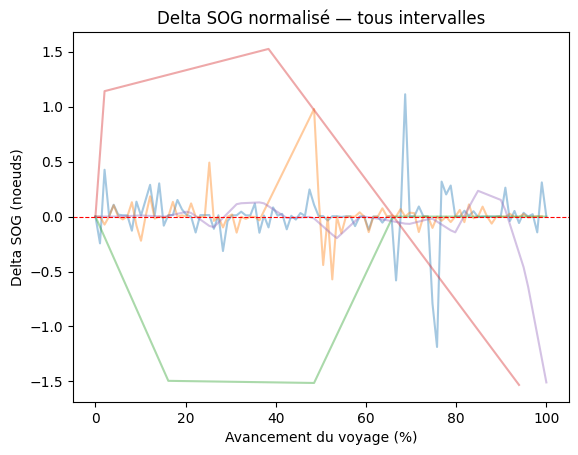

In [21]:
import matplotlib.pyplot as plt

for id_int in df_serie["id_intervalle"].unique()[:5]:  # 5 premiers
    seg = df_serie[df_serie["id_intervalle"] == id_int]
    plt.plot(seg["avancee_pct"], seg["delta_sog"], alpha=0.4)

plt.axhline(0, color="red", linestyle="--", linewidth=0.8)
plt.xlabel("Avancement du voyage (%)")
plt.ylabel("Delta SOG (noeuds)")
plt.title("Delta SOG normalisé — tous intervalles")
plt.show()

Intervalles traités  : 120
Intervalles exclus   : 1750


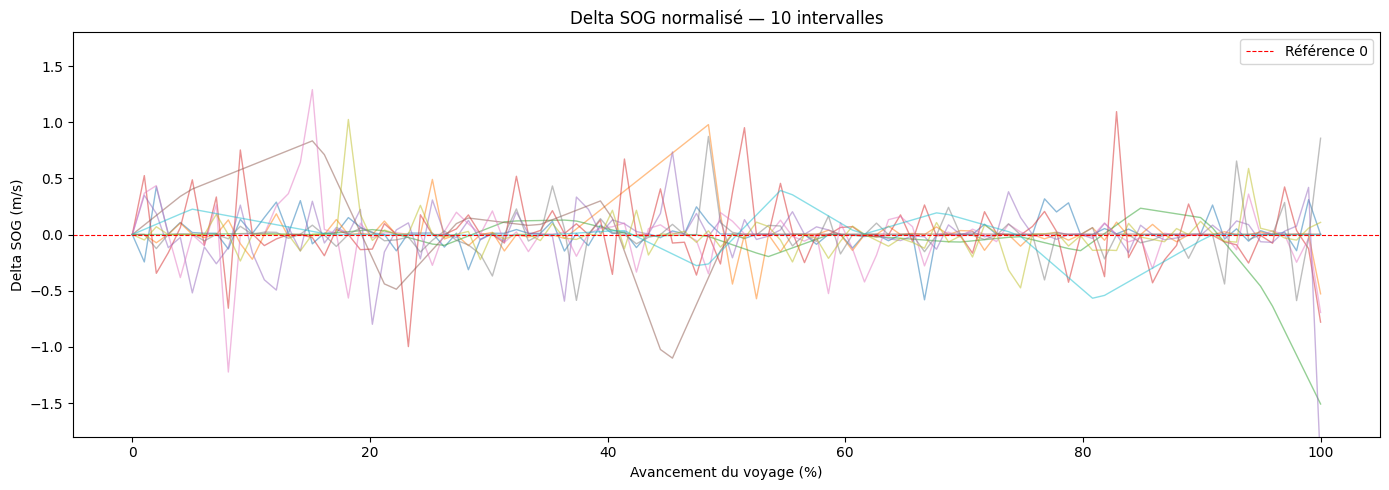

/tmp/ipykernel_527414/1028578651.py:165: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(serie, regression="c", nlags="auto")
/tmp/ipykernel_527414/1028578651.py:165: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(serie, regression="c", nlags="auto")
/tmp/ipykernel_527414/1028578651.py:165: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(serie, regression="c", nlags="auto")
/tmp/ipykernel_527414/1028578651.py:165: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is 

conclusion
Stationnaire        71
Non stationnaire    28
Ambigu              21
Name: count, dtype: int64
     id_intervalle  adf_pvalue  kpss_pvalue    conclusion
0              1.0      0.0000       0.1000  Stationnaire
1              4.0      0.0387       0.1000  Stationnaire
2              7.0      0.8991       0.0730        Ambigu
3              9.0      0.0000       0.1000  Stationnaire
4             11.0      0.0000       0.1000  Stationnaire
..             ...         ...          ...           ...
115         1863.0      0.0050       0.1000  Stationnaire
116         1864.0      0.0000       0.1000  Stationnaire
117         1867.0      0.0004       0.1000  Stationnaire
118         1869.0      0.0000       0.0543  Stationnaire
119         1870.0      0.0000       0.1000  Stationnaire

[120 rows x 4 columns]


/tmp/ipykernel_527414/1028578651.py:165: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(serie, regression="c", nlags="auto")
/tmp/ipykernel_527414/1028578651.py:165: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(serie, regression="c", nlags="auto")


In [22]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════════════════════════════════════════
# ÉTAPE 1 — Construction de la série normalisée (corrigée)
# ═══════════════════════════════════════════════════════════════════════════════

def construire_serie_normalisee(
    df_enrichi: pd.DataFrame,
    n_points: int = 100,
    seuil_delta: float = 3.0,
    min_points: int = 10,
    cols_exogenes: list = ["dist_cote_km", "wind_speed"]
) -> pd.DataFrame:
    """
    Construit une série temporelle normalisée du Delta SOG
    sur une grille d'avancement 0% → 100% pour chaque intervalle.

    Corrections intégrées :
        - Calcul du delta_sog AVANT interpolation
        - Exclusion des valeurs aberrantes AVANT interpolation
        - Seuil minimum de points par intervalle
        - Conversion en m/s

    Parameters
    ----------
    df_enrichi  : DataFrame enrichi par decouper_intervalles()
    n_points    : nombre de points sur la grille normalisée (défaut 100)
    seuil_delta : seuil en noeuds pour exclure les aberrants (défaut 3.0)
    min_points  : nombre minimum de points pour traiter un intervalle
    cols_exogenes : colonnes exogènes à interpoler

    Returns
    -------
    DataFrame avec colonnes :
        - 'id_intervalle' : identifiant de l'intervalle
        - 'avancee_pct'   : grille 0 à 100
        - 'delta_sog_ms'  : accélération en m/s
        - colonnes exogènes interpolées
    """

    KNOTS_TO_MS = 0.514444
    grille      = np.linspace(0, 100, n_points)
    series      = []
    exclus      = 0

    for id_int in df_enrichi["id_intervalle"].dropna().unique():

        seg = df_enrichi[df_enrichi["id_intervalle"] == id_int].copy()
        seg = seg.sort_values("timestamp").reset_index(drop=True)

        # ── 1. Calcul du delta SOG (en noeuds) ────────────────────────────────
        seg["delta_sog"] = seg["sog"].diff().fillna(0)

        # ── 2. Exclusion des aberrants AVANT interpolation ────────────────────
        seg = seg[seg["delta_sog"].abs() <= seuil_delta]

        # ── 3. Vérification du nombre de points ───────────────────────────────
        if len(seg) < min_points:
            exclus += 1
            continue

        # ── 4. Recalcul de l'avancée après filtrage ───────────────────────────
        avancee = seg["avancee_pct"].values

        # ── 5. Conversion en m/s ──────────────────────────────────────────────
        delta_sog_ms = seg["delta_sog"].values * KNOTS_TO_MS

        # ── 6. Interpolation sur grille normalisée ────────────────────────────
        f_delta = interp1d(avancee, delta_sog_ms,
                           kind="linear", bounds_error=False,
                           fill_value="extrapolate")

        row = {
            "id_intervalle": id_int,
            "avancee_pct":   grille,
            "delta_sog_ms":  f_delta(grille)
        }

        # ── 7. Interpolation des variables exogènes ───────────────────────────
        for col in cols_exogenes:
            if col in seg.columns and seg[col].notna().sum() >= min_points:
                f_exo = interp1d(avancee, seg[col].values,
                                 kind="linear", bounds_error=False,
                                 fill_value="extrapolate")
                row[col] = f_exo(grille)
            else:
                row[col] = np.nan

        series.append(pd.DataFrame(row))

    print(f"Intervalles traités  : {len(series)}")
    print(f"Intervalles exclus   : {exclus}")

    return pd.concat(series, ignore_index=True)


# ═══════════════════════════════════════════════════════════════════════════════
# ÉTAPE 2 — Visualisation
# ═══════════════════════════════════════════════════════════════════════════════

def plot_serie_normalisee(df_serie: pd.DataFrame, n_affich: int = 10) -> None:
    """
    Affiche les courbes de delta_sog_ms normalisées.

    Parameters
    ----------
    df_serie  : DataFrame issu de construire_serie_normalisee()
    n_affich  : nombre d'intervalles à afficher (défaut 10)
    """

    ids = df_serie["id_intervalle"].unique()[:n_affich]

    fig, ax = plt.subplots(figsize=(14, 5))

    for id_int in ids:
        seg = df_serie[df_serie["id_intervalle"] == id_int]
        ax.plot(seg["avancee_pct"], seg["delta_sog_ms"], alpha=0.5, linewidth=1.0)

    ax.axhline(0, color="red", linestyle="--", linewidth=0.8, label="Référence 0")
    ax.set_ylim(-1.8, 1.8)  # ±3 noeuds convertis en m/s
    ax.set_xlabel("Avancement du voyage (%)")
    ax.set_ylabel("Delta SOG (m/s)")
    ax.set_title(f"Delta SOG normalisé — {len(ids)} intervalles")
    ax.legend()

    plt.tight_layout()
    plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# ÉTAPE 3 — Test de stationnarité
# ═══════════════════════════════════════════════════════════════════════════════

from statsmodels.tsa.stattools import adfuller, kpss

def tester_stationnarite(df_serie: pd.DataFrame) -> pd.DataFrame:
    """
    Teste la stationnarité du delta_sog_ms pour chaque intervalle
    via les tests ADF et KPSS.

    Returns
    -------
    DataFrame avec pour chaque intervalle :
        - p_value ADF  (H0 : non stationnaire → p faible = stationnaire)
        - p_value KPSS (H0 : stationnaire     → p faible = non stationnaire)
        - conclusion
    """

    resultats = []

    for id_int in df_serie["id_intervalle"].unique():

        serie = df_serie[df_serie["id_intervalle"] == id_int]["delta_sog_ms"].dropna()

        if len(serie) < 20:
            continue

        # Test ADF
        adf_stat, adf_p, *_ = adfuller(serie, autolag="AIC")

        # Test KPSS
        kpss_stat, kpss_p, *_ = kpss(serie, regression="c", nlags="auto")

        # Conclusion
        if adf_p < 0.05 and kpss_p > 0.05:
            conclusion = "Stationnaire"
        elif adf_p >= 0.05 and kpss_p <= 0.05:
            conclusion = "Non stationnaire"
        else:
            conclusion = "Ambigu"

        resultats.append({
            "id_intervalle": id_int,
            "adf_pvalue":    round(adf_p, 4),
            "kpss_pvalue":   round(kpss_p, 4),
            "conclusion":    conclusion
        })

    df_res = pd.DataFrame(resultats)

    print(df_res["conclusion"].value_counts())
    return df_res


# ═══════════════════════════════════════════════════════════════════════════════
# PIPELINE COMPLET
# ═══════════════════════════════════════════════════════════════════════════════

# 1. Construction
df_serie = construire_serie_normalisee(
    df_enrichi,
    n_points      = 100,
    seuil_delta   = 3.0,
    min_points    = 10,
    cols_exogenes = ["dist_cote_km", "wind_speed"]
)

# 2. Visualisation
plot_serie_normalisee(df_serie, n_affich=10)

# 3. Stationnarité
df_stat = tester_stationnarite(df_serie)
print(df_stat)

In [23]:
df_stat = tester_stationnarite(df_serie)
print(df_stat)

/tmp/ipykernel_527414/1028578651.py:165: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(serie, regression="c", nlags="auto")
/tmp/ipykernel_527414/1028578651.py:165: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(serie, regression="c", nlags="auto")
/tmp/ipykernel_527414/1028578651.py:165: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(serie, regression="c", nlags="auto")
/tmp/ipykernel_527414/1028578651.py:165: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is 

conclusion
Stationnaire        71
Non stationnaire    28
Ambigu              21
Name: count, dtype: int64
     id_intervalle  adf_pvalue  kpss_pvalue    conclusion
0              1.0      0.0000       0.1000  Stationnaire
1              4.0      0.0387       0.1000  Stationnaire
2              7.0      0.8991       0.0730        Ambigu
3              9.0      0.0000       0.1000  Stationnaire
4             11.0      0.0000       0.1000  Stationnaire
..             ...         ...          ...           ...
115         1863.0      0.0050       0.1000  Stationnaire
116         1864.0      0.0000       0.1000  Stationnaire
117         1867.0      0.0004       0.1000  Stationnaire
118         1869.0      0.0000       0.0543  Stationnaire
119         1870.0      0.0000       0.1000  Stationnaire

[120 rows x 4 columns]


/tmp/ipykernel_527414/1028578651.py:165: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(serie, regression="c", nlags="auto")
/tmp/ipykernel_527414/1028578651.py:165: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(serie, regression="c", nlags="auto")
/tmp/ipykernel_527414/1028578651.py:165: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(serie, regression="c", nlags="auto")
/tmp/ipykernel_527414/1028578651.py:165: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is 

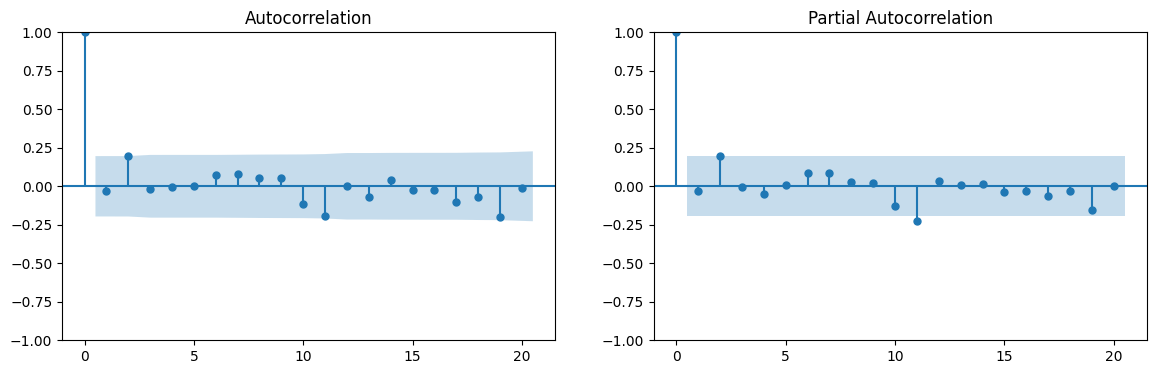

In [24]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ids_stationnaires = df_stat[df_stat["conclusion"] == "Stationnaire"]["id_intervalle"]
serie_ref = df_serie[df_serie["id_intervalle"] == ids_stationnaires.iloc[0]]["delta_sog_ms"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(serie_ref, lags=20, ax=axes[0])
plot_pacf(serie_ref, lags=20, ax=axes[1])
plt.show()

In [25]:
from statsmodels.stats.diagnostic import acorr_ljungbox

def tester_bruit_blanc(df_serie: pd.DataFrame, lags: int = 10) -> pd.DataFrame:
    """
    Teste si le delta_sog_ms est un bruit blanc pour chaque intervalle
    via le test de Ljung-Box.

    H0 : bruit blanc → ARMA inutile
    H1 : structure autocorrélée → ARMA justifié
    """

    resultats = []

    for id_int in df_serie["id_intervalle"].dropna().unique():

        serie = df_serie[df_serie["id_intervalle"] == id_int]["delta_sog_ms"].dropna()

        if len(serie) < 20:
            continue

        lb = acorr_ljungbox(serie, lags=[lags], return_df=True)

        p_value   = lb["lb_pvalue"].values[0]
        structure = "ARMA justifié" if p_value < 0.05 else "Bruit blanc"

        resultats.append({
            "id_intervalle": id_int,
            "lb_stat":       round(lb["lb_stat"].values[0], 4),
            "lb_pvalue":     round(p_value, 4),
            "conclusion":    structure
        })

    df_res = pd.DataFrame(resultats)

    print("=" * 40)
    print(df_res["conclusion"].value_counts())
    print("=" * 40)

    return df_res

In [26]:
df_bb = tester_bruit_blanc(df_serie, lags=10)

conclusion
ARMA justifié    71
Bruit blanc      49
Name: count, dtype: int64


In [27]:
df_diagnostic = df_stat.merge(df_bb, on="id_intervalle")
print(df_diagnostic.groupby(["conclusion_x", "conclusion_y"]).size())

conclusion_x      conclusion_y 
Ambigu            ARMA justifié    17
                  Bruit blanc       4
Non stationnaire  ARMA justifié    28
Stationnaire      ARMA justifié    26
                  Bruit blanc      45
dtype: int64


In [28]:
# Ensemble 1 — ARMA(2,3)
ids_arma = df_diagnostic[
    (df_diagnostic["conclusion_x"] == "Stationnaire") &
    (df_diagnostic["conclusion_y"] == "ARMA justifié")
]["id_intervalle"]

# Ensemble 2 — ARIMA(2,1,3)
ids_arima = df_diagnostic[
    (df_diagnostic["conclusion_x"] == "Non stationnaire") &
    (df_diagnostic["conclusion_y"] == "ARMA justifié")
]["id_intervalle"]

print(f"Intervalles ARMA  : {len(ids_arma)}")
print(f"Intervalles ARIMA : {len(ids_arima)}")

Intervalles ARMA  : 26
Intervalles ARIMA : 28


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import itertools

def selectionner_ordres(serie, p_max=3, q_max=3):
    meilleur_aic = np.inf
    meilleur_ordre = None

    for p, q in itertools.product(range(p_max+1), range(q_max+1)):
        try:
            modele = ARIMA(serie, order=(p, 0, q)).fit()
            if modele.aic < meilleur_aic:
                meilleur_aic   = modele.aic
                meilleur_ordre = (p, q)
        except:
            continue

    print(f"Meilleur ordre : ARMA{meilleur_ordre} — AIC : {meilleur_aic:.2f}")
    return meilleur_ordre

# Sur les intervalles stationnaires
ids_stat = df_stat[df_stat["conclusion"] == "Stationnaire"]["id_intervalle"]

ordres = []
for id_int in ids_stat:
    serie = df_serie[df_serie["id_intervalle"] == id_int]["delta_sog_ms"].dropna()
    ordres.append(selectionner_ordres(serie))

# Ordre le plus fréquent
from collections import Counter
print(Counter(ordres).most_common(5))

/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmo

Meilleur ordre : ARMA(0, 2) — AIC : -128.82


/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupport

Meilleur ordre : ARMA(2, 0) — AIC : -63.52


/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupport

...

/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupport

Meilleur ordre : ARMA(2, 3) — AIC : 46.73


/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupport

Meilleur ordre : ARMA(1, 1) — AIC : -68.14


/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/onyxia/work/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupport

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import normaltest
import matplotlib.pyplot as plt

def tester_ordre_arma(df_serie, id_int, ordre=(2,3)):
    """
    Ajuste un ARMA sur un intervalle et teste la qualité des résidus.

    Tests effectués :
        - Ljung-Box   : les résidus sont-ils un bruit blanc ?
        - Normalité   : les résidus suivent-ils une loi normale ?
        - Visualisation : résidus, ACF résidus, QQ-plot
    """

    serie = df_serie[df_serie["id_intervalle"] == id_int]["delta_sog_ms"].dropna()
    p, q  = ordre

    # ── 1. Ajustement ─────────────────────────────────────────────────────────
    modele  = ARIMA(serie, order=(p, 0, q)).fit()
    residus = modele.resid

    print(modele.summary())

    # ── 2. Test Ljung-Box sur les résidus ─────────────────────────────────────
    lb = acorr_ljungbox(residus, lags=[10], return_df=True)
    print(f"\nLjung-Box résidus — p-value : {lb['lb_pvalue'].values[0]:.4f}")
    print("→ Bruit blanc ✅" if lb['lb_pvalue'].values[0] > 0.05 else "→ Structure résiduelle ❌")

    # ── 3. Test de normalité des résidus ──────────────────────────────────────
    stat, p_norm = normaltest(residus)
    print(f"\nTest normalité résidus — p-value : {p_norm:.4f}")
    print("→ Résidus normaux ✅" if p_norm > 0.05 else "→ Résidus non normaux ⚠️")

    # ── 4. Visualisation ──────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Résidus au cours du temps
    axes[0].plot(residus.values, color="steelblue", linewidth=0.8)
    axes[0].axhline(0, color="red", linestyle="--")
    axes[0].set_title("Résidus")

    # ACF des résidus
    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(residus, lags=20, ax=axes[1])
    axes[1].set_title("ACF Résidus")

    # QQ-plot
    from scipy.stats import probplot
    probplot(residus, plot=axes[2])
    axes[2].set_title("QQ-plot Résidus")

    plt.suptitle(f"Diagnostic ARMA{ordre} — Intervalle {id_int}", fontweight="bold")
    plt.tight_layout()
    plt.show()

    return modele

In [ ]:
# Tester sur un intervalle
modele = tester_ordre_arma(df_serie, id_int=ids_arma.iloc[0], ordre=(1,0))

# Tester sur tous les intervalles ARMA justifiés
resultats_diagnostic = []
for id_int in ids_arma:
    m = tester_ordre_arma(df_serie, id_int, ordre=(2,3))
    resultats_diagnostic.append({
        "id_intervalle": id_int,
        "aic":           m.aic,
        "bic":           m.bic
    })

In [ ]:
coefficients = []
for id_int in ids_arma:
    serie = df_serie[df_serie["id_intervalle"] == id_int]["delta_sog_ms"].dropna()
    serie.index = pd.RangeIndex(len(serie))
    m = ARIMA(serie, order=(1,0,0)).fit()
    coefficients.append({
        "id_intervalle": id_int,
        "ar1":           m.params["ar.L1"],
        "const":         m.params["const"],
        "aic":           m.aic
    })

df_coef = pd.DataFrame(coefficients)
print(df_coef.describe())

In [ ]:
def analyser_heterogeneite_ar1(df_coef: pd.DataFrame, df_enrichi: pd.DataFrame) -> pd.DataFrame:
    """
    Analyse la corrélation entre le coefficient AR(1) et les
    caractéristiques des voyages.
    """

    # ── 1. Caractéristiques par intervalle ────────────────────────────────────
    caract = df_enrichi.groupby("id_intervalle").agg(
        duree_h        = ("duree_h",       "first"),
        sog_moyenne    = ("sog",           "mean"),
        sog_std        = ("sog",           "std"),
        dist_cote_mean = ("dist_cote_km",  "mean"),
        n_points       = ("sog",           "count")
    ).reset_index()

    # ── 2. Fusion avec les coefficients AR(1) ─────────────────────────────────
    df_analyse = df_coef.merge(caract, on="id_intervalle")

    # ── 3. Corrélations avec ar1 ──────────────────────────────────────────────
    cols = ["duree_h", "sog_moyenne", "sog_std", "dist_cote_mean", "n_points"]

    print("=" * 45)
    print("CORRÉLATIONS AVEC LE COEFFICIENT AR(1)")
    print("=" * 45)
    for col in cols:
        r = df_analyse["ar1"].corr(df_analyse[col])
        print(f"{col:<20} : r = {r:.3f}")
    print("=" * 45)

    # ── 4. Visualisation ──────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        axes[i].scatter(df_analyse[col], df_analyse["ar1"], alpha=0.7, color="steelblue")
        axes[i].axhline(0, color="red", linestyle="--", linewidth=0.8)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("AR(1)")

        # Droite de régression
        z = np.polyfit(df_analyse[col].dropna(), 
                       df_analyse.loc[df_analyse[col].notna(), "ar1"], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df_analyse[col].min(), df_analyse[col].max(), 100)
        axes[i].plot(x_line, p(x_line), color="orange", linewidth=1.5)

    plt.suptitle("Hétérogénéité du coefficient AR(1) selon les caractéristiques du voyage",
                 fontweight="bold", fontsize=13)
    plt.tight_layout()
    plt.show()

    return df_analyse

In [ ]:
df_analyse = analyser_heterogeneite_ar1(df_coef, df_enrichi)

# Nouvelle approche : approche par clusters de ports

In [ ]:
import sys
sys.path.append("/home/onyxia/work/gtt/Anthony/ajout_ports.py")

from ajout_ports import associer_ports, distance_cote
from enrichissement_ais import enrichir_ais


In [ ]:
navires_sample = pd.Series(df["mmsi"].unique()).sample(n=20, random_state=42)
df_sample = df[df["mmsi"].isin(navires_sample)].copy()

print(f"Taille du sample : {len(df_sample):,} lignes")
print(f"Navires : {df_sample['mmsi'].nunique()}")

Taille du sample : 334,181 lignes
Navires : 20


In [ ]:

df_ports      = associer_ports(df_sample, "upply-seaports.csv")


/home/onyxia/work/gtt/Anthony/ajout_ports.py:50: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["dist_cote_km"] = gdf.geometry.distance(cotes) * 111


ASSOCIATION DES PORTS
Voyages total             : 703
Exclus (filtre côte)      : 24  (>100 km de la côte)

Distance au port attribué (départ) :
count    686.0
mean      30.2
std       31.4
min        0.1
25%       10.7
50%       18.7
75%       35.8
max      171.1

Distance au port attribué (arrivée) :
count    688.0
mean      28.4
std       31.1
min        0.2
25%        9.2
50%       15.6
75%       35.2
max      180.9

Exclus (filtre port)      : 158  (>50 km du port attribué)
Voyages conservés         : 521  (74.1 % du total)

Ports de départ identifiés :
port_depart_name
Ras Laffan                    183
Fa'id                         104
Tanjung Pelepas                78
Khor al Fakkan                 37
Dahej                          25
Muhammad Bin Qasim/Karachi     22
Tanjong Bin                    15
Sokhna Port                     9
Jebel Ali Free Zone             7
Mina' al Ahmadi                 7

Ports d'arrivée identifiés :
port_arrivee_name
Ras Laffan                    

In [ ]:
"""
Étape 1 — Attribution des secteurs géographiques par règles métier.

Dépendances :
    - ajout_ports.py  (fonctions associer_ports, distance_cote)

Pipeline :
    df_ais  →  associer_ports()  →  attribuer_region()  →  attribuer_secteur()  →  df_sectorise
"""

from pathlib import Path

import pandas as pd

# ---------------------------------------------------------------------------
# 1. Dictionnaire des régions
#    Clé   : nom de port tel que retourné par associer_ports()
#    Valeur : région géographique
# ---------------------------------------------------------------------------

REGIONS: dict[str, str] = {
    # ── Golfe Persique ───────────────────────────────────────────────────────
    "Ras Laffan":          "Golfe Persique",
    "Mina' al Ahmadi":     "Golfe Persique",
    "Das Island":          "Golfe Persique",
    "Dubai":               "Golfe Persique",
    "Abu Dhabi":           "Golfe Persique",
    "Khor al Fakkan":      "Golfe Persique",
    "Fujairah":            "Golfe Persique",
    "Sohar":               "Golfe Persique",
    "Sur":                 "Golfe Persique",
    "Hulaylah Terminal":   "Golfe Persique",   # terminal pétrolier, Qatar
    "Mina Al Zour":        "Golfe Persique",   # terminal GNL, Koweït
    "Zirku Island":        "Golfe Persique",   # terminal offshore, Abu Dhabi

    # ── Mer Rouge / Canal de Suez ────────────────────────────────────────────
    "'Aqaba":              "Mer Rouge",
    "Aqaba":               "Mer Rouge",
    "Jeddah":              "Mer Rouge",
    "Djibouti":            "Mer Rouge",
    "As Suways (Suez)":    "Mer Rouge",        # entrée sud du canal
    "Fa'id":               "Mer Rouge",        # lac Amer, zone canal
    "Sokhna Port":         "Mer Rouge",        # port industriel, Égypte

    # ── Afrique de l'Est ─────────────────────────────────────────────────────
    "Mombasa":             "Afrique de l'Est",
    "Dar es Salaam":       "Afrique de l'Est",
    "Maputo":              "Afrique de l'Est",

    # ── Afrique du Sud / Cap ─────────────────────────────────────────────────
    "Cape Town":           "Afrique du Sud",
    "Port Elizabeth":      "Afrique du Sud",
    "Durban":              "Afrique du Sud",
    "Richards Bay":        "Afrique du Sud",
    "Goudiniweg":          "Afrique du Sud",   # terminal intérieur, Western Cape
    "Riviersonderend":     "Afrique du Sud",   # Western Cape

    # ── Inde / Sous-continent ────────────────────────────────────────────────
    "Mumbai":              "Inde",
    "Mundra":              "Inde",
    "Port of Mundra":      "Inde",             # variante du nom
    "Kandla":              "Inde",
    "Chennai":             "Inde",
    "Ennore":              "Inde",             # port de Kamarajar, nord Chennai
    "Kochi":               "Inde",
    "Cochin":              "Inde",             # ancien nom de Kochi
    "Hazira":              "Inde",
    "Hazira Port/Surat":   "Inde",             # variante du nom
    "Dahej":               "Inde",
    "Dighi (Pune)":        "Inde",             # port de Dighi, Maharashtra
    "Chattogram":          "Inde",             # Bangladesh (sous-continent)

    # ── Détroit de Malacca / Asie du Sud-Est ─────────────────────────────────
    "Tanjong Bin":         "Détroit de Malacca",
    "Tanjung Pelepas":     "Détroit de Malacca",
    "Port Dickson":        "Détroit de Malacca",
    "Sungai Udang":        "Détroit de Malacca",
    "Singapore":           "Détroit de Malacca",
    "Malacca":             "Détroit de Malacca",  # port de Malacca, Malaisie
    "Nilai":               "Détroit de Malacca",  # port sec, Malaisie
    "Anyer Kidul":         "Détroit de Malacca",  # Indonésie, détroit de la Sonde
    "Perawang":            "Détroit de Malacca",  # Sumatra, Indonésie
    "Pulau Jarak":         "Détroit de Malacca",  # île malaisienne, détroit
    "Tarahan":             "Détroit de Malacca",  # terminal charbon, Sumatra
    "Free Port":           "Détroit de Malacca",  # zone franche, Malaisie

    # ── Australie ────────────────────────────────────────────────────────────
    "Dampier":             "Australie",
    "Port Hedland":        "Australie",
    "Karratha":            "Australie",
    "Fremantle":           "Australie",
    "Gladstone":           "Australie",
}

# ---------------------------------------------------------------------------
# 2. Attribuer une région à chaque port
# ---------------------------------------------------------------------------

def attribuer_region(nom_port: str | None) -> str | None:
    """
    Retourne la région associée à un nom de port.
    Retourne None si le port est inconnu ou manquant.

    La comparaison est insensible à la casse et aux espaces superflus.
    """
    if not isinstance(nom_port, str):
        return None

    nom_normalise = nom_port.strip()

    # Correspondance exacte (rapide)
    if nom_normalise in REGIONS:
        return REGIONS[nom_normalise]

    # Correspondance insensible à la casse (fallback)
    nom_lower = nom_normalise.lower()
    for port, region in REGIONS.items():
        if port.lower() == nom_lower:
            return region

    return None


# ---------------------------------------------------------------------------
# 3. Construire le label de secteur à partir des deux régions
# ---------------------------------------------------------------------------

def _label_secteur(region_dep: str | None, region_arr: str | None) -> str | None:
    """
    Construit un label de secteur canonique à partir de deux régions.

    La route est symétrique : A→B et B→A appartiennent au même secteur.
    Les noms sont triés alphabétiquement pour garantir l'unicité du label.

    Retourne None si l'une des deux régions est inconnue.
    """
    if region_dep is None or region_arr is None:
        return None

    paire = sorted([region_dep, region_arr])
    return f"{paire[0]} ↔ {paire[1]}"


# ---------------------------------------------------------------------------
# 4. Fonction principale
# ---------------------------------------------------------------------------

def attribuer_secteur(df_ports: pd.DataFrame) -> pd.DataFrame:
    """
    Ajoute les colonnes 'region_depart', 'region_arrivee' et 'secteur'
    au DataFrame produit par associer_ports(), puis exclut les trajets
    dont les ports ne correspondent à aucune règle métier.

    Paramètres
    ----------
    df_ports : pd.DataFrame
        Sortie de associer_ports() — doit contenir au minimum :
        'voyage number', 'mmsi', 'port_depart_name', 'port_arrivee_name'.

    Retour
    ------
    pd.DataFrame
        DataFrame filtré avec les colonnes supplémentaires :
        'region_depart', 'region_arrivee', 'secteur'.
    """
    df = df_ports.copy()

    # Régions
    df["region_depart"]  = df["port_depart_name"].map(attribuer_region)
    df["region_arrivee"] = df["port_arrivee_name"].map(attribuer_region)

    # Secteur
    df["secteur"] = df.apply(
        lambda r: _label_secteur(r["region_depart"], r["region_arrivee"]),
        axis=1,
    )

    # Diagnostics avant filtrage
    n_total   = len(df)
    n_exclus  = df["secteur"].isna().sum()
    n_conserve = n_total - n_exclus

    print("=" * 50)
    print("ATTRIBUTION DES SECTEURS")
    print("=" * 50)
    print(f"Trajets total      : {n_total:,}")
    print(f"Trajets exclus     : {n_exclus:,}  ({n_exclus / n_total * 100:.1f} %)")
    print(f"Trajets conservés  : {n_conserve:,}  ({n_conserve / n_total * 100:.1f} %)")
    print()
    print("Répartition par secteur :")
    print(df["secteur"].value_counts().to_string())
    print("=" * 50)

    # Exclusion des trajets sans secteur
    df = df[df["secteur"].notna()].reset_index(drop=True)

    return df


# ---------------------------------------------------------------------------
# 5. Joindre le secteur au DataFrame AIS complet
# ---------------------------------------------------------------------------

def joindre_secteur_ais(df_ais: pd.DataFrame, df_sectorise: pd.DataFrame) -> pd.DataFrame:
    """
    Propage la colonne 'secteur' (et les régions) du DataFrame de ports
    vers le DataFrame AIS complet, en joignant sur ('voyage number', 'mmsi').

    Les lignes AIS appartenant à un trajet sans secteur sont exclues.

    Paramètres
    ----------
    df_ais        : DataFrame AIS brut (ou enrichi par decouper_intervalles)
    df_sectorise  : sortie de attribuer_secteur()

    Retour
    ------
    pd.DataFrame
        df_ais avec les colonnes 'region_depart', 'region_arrivee', 'secteur'.
    """
    cols_secteur = ["voyage number", "mmsi", "region_depart", "region_arrivee", "secteur"]

    df_merged = df_ais.merge(
        df_sectorise[cols_secteur],
        on=["voyage number", "mmsi"],
        how="inner",   # exclut les trajets sans secteur
    )

    print(f"Lignes AIS avant jointure : {len(df_ais):,}")
    print(f"Lignes AIS après jointure : {len(df_merged):,}")

    return df_merged




    # Échantillon de test
mmsi_sample = (
        pd.Series(df["mmsi"].dropna().unique())
        .sample(n=10, random_state=75)
    )
df_sample = df[df["mmsi"].isin(mmsi_sample)].copy()

    # Pipeline complet
df_ports      = associer_ports(df_sample, "upply-seaports.csv", seuil_cote_km=100)
df_sectorise  = attribuer_secteur(df_ports)
#df_ais_sector = joindre_secteur_ais(df_sample, df_sectorise)
df_ais_sector = enrichir_ais(df_sample, df_sectorise)
print(df_ais_sector[["voyage number", "mmsi", "secteur"]].drop_duplicates().head(20))


/home/onyxia/work/gtt/Anthony/ajout_ports.py:50: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["dist_cote_km"] = gdf.geometry.distance(cotes) * 111


ASSOCIATION DES PORTS
Voyages total             : 302
Exclus (filtre côte)      : 119  (>100 km de la côte)

Distance au port attribué (départ) :
count    183.0
mean      35.2
std       31.1
min        0.8
25%       15.0
50%       26.9
75%       38.7
max      125.1

Distance au port attribué (arrivée) :
count    184.0
mean      38.5
std       35.6
min        0.2
25%       16.5
50%       25.3
75%       42.3
max      169.4

Exclus (filtre port)      : 49  (>50 km du port attribué)
Voyages conservés         : 134  (44.4 % du total)

Ports de départ identifiés :
port_depart_name
Tanjung Pelepas      33
Fa'id                30
Khor al Fakkan       26
Dahej                15
Ras Laffan            9
Tanjong Bin           6
Mina Al Zour          3
Sokhna Port           2
Port of Mundra        2
Hazira Port/Surat     2

Ports d'arrivée identifiés :
port_arrivee_name
Khor al Fakkan     31
Fa'id              27
Tanjung Pelepas    21
Ras Laffan         12
Tanjong Bin        12
Dahej              1

In [ ]:
df_ais_sector = joindre_secteur_ais(df_sample, df_sectorise)

Lignes AIS avant jointure : 121,718
Lignes AIS après jointure : 56,310


In [ ]:
"""
Étape 1 — Détection des seuils de régime par secteur.

Pour chaque secteur, on estime :
    - seuil_D : distance au port de départ (km) en dessous de laquelle
                le navire est en régime DÉPART (accélération)
    - seuil_A : distance au port d'arrivée (km) en dessous de laquelle
                le navire est en régime ARRIVÉE (décélération)

Méthode :
    On calcule le profil moyen de SOG en fonction de la distance au port
    (départ ou arrivée), puis on détecte la rupture par la méthode de
    Pettitt (non-paramétrique, robuste aux outliers) sur ce profil moyen.
    Si Pettitt échoue ou n'est pas significatif, on replie sur une détection
    par seuil de gradient (plus grande variation du profil lissé).

Dépendances :
    pip install ruptures
    enrichissement_ais.py  (colonnes dist_port_depart_km, dist_port_arrivee_km)

Colonnes attendues dans df_enrichi :
    mmsi, voyage number, secteur, sog,
    dist_port_depart_km, dist_port_arrivee_km
"""

from __future__ import annotations

import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import ruptures as rpt


# ---------------------------------------------------------------------------
# Résultat par secteur
# ---------------------------------------------------------------------------

@dataclass
class SeuilsRegime:
    secteur:   str
    seuil_D:   float   # km, seuil régime DÉPART
    seuil_A:   float   # km, seuil régime ARRIVÉE
    methode_D: str     # "pettitt" | "gradient"
    methode_A: str     # "pettitt" | "gradient"
    n_voyages: int


# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def _profil_moyen_sog(
    series_dist: pd.Series,
    series_sog:  pd.Series,
    n_bins: int = 40,
    dist_max_km: float = 500,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Calcule le profil moyen de SOG en fonction de la distance au port.

    Retourne (centres_bins_km, sog_moyen) — deux arrays de longueur n_bins.
    Les bins vides sont interpolés linéairement.
    """
    mask = series_dist <= dist_max_km
    bins = np.linspace(0, dist_max_km, n_bins + 1)
    centres = (bins[:-1] + bins[1:]) / 2

    sog_mean = (
        pd.cut(series_dist[mask], bins=bins, labels=centres)
        .rename("bin")
        .to_frame()
        .assign(sog=series_sog[mask].values)
        .groupby("bin")["sog"]
        .mean()
        .reindex(centres)
    )

    # Interpolation des bins vides
    sog_interp = sog_mean.interpolate(method="linear").fillna(method="bfill").fillna(method="ffill")

    return centres, sog_interp.values


def _detecter_rupture_pettitt(signal: np.ndarray) -> int | None:
    """
    Détecte le point de changement le plus probable dans un signal 1D
    par l'algorithme Pettitt (implémenté via ruptures Binseg + coût L2).

    Retourne l'indice de rupture, ou None si non significatif
    (amplitude < 1 nœud entre les deux segments).
    """
    try:
        model = rpt.Binseg(model="l2", min_size=3).fit(signal.reshape(-1, 1))
        bkps  = model.predict(n_bkps=1)
        idx   = bkps[0] - 1  # ruptures retourne l'indice exclusif

        # Significativité : différence de moyennes > 1 nœud
        mu_avant = signal[:idx].mean()
        mu_apres = signal[idx:].mean()
        if abs(mu_avant - mu_apres) < 1.0:
            return None

        return int(idx)

    except Exception:
        return None


def _detecter_rupture_gradient(signal: np.ndarray, centres: np.ndarray) -> int:
    """
    Repli : détecte le seuil par la position du gradient maximal
    sur le signal lissé (fenêtre 3 points).
    """
    lisse  = np.convolve(signal, np.ones(3) / 3, mode="same")
    grad   = np.abs(np.gradient(lisse))
    return int(np.argmax(grad))


def _seuil_depuis_indice(idx: int, centres: np.ndarray) -> float:
    """Convertit un indice de bin en distance km (centre du bin)."""
    return float(centres[min(idx, len(centres) - 1)])


# ---------------------------------------------------------------------------
# Fonction principale
# ---------------------------------------------------------------------------

def estimer_seuils(
    df_enrichi: pd.DataFrame,
    n_bins: int = 40,
    dist_max_km: float = 500,
    seuil_D_defaut: float = 150,
    seuil_A_defaut: float = 150,
) -> pd.DataFrame:
    """
    Estime seuil_D et seuil_A pour chaque secteur.

    Paramètres
    ----------
    df_enrichi : pd.DataFrame
        Sortie de enrichir_ais() — doit contenir :
        'secteur', 'sog', 'dist_port_depart_km', 'dist_port_arrivee_km',
        'voyage number', 'mmsi'.
    n_bins : int
        Nombre de bins pour le profil moyen de SOG. Défaut : 40.
    dist_max_km : float
        Distance maximale considérée pour le profil (km). Défaut : 500.
    seuil_D_defaut : float
        Valeur de repli si la détection échoue (km). Défaut : 150.
    seuil_A_defaut : float
        Valeur de repli si la détection échoue (km). Défaut : 150.

    Retour
    ------
    pd.DataFrame
        Une ligne par secteur avec les colonnes :
        'secteur', 'seuil_D', 'seuil_A', 'methode_D', 'methode_A', 'n_voyages'.
    """
    resultats: list[SeuilsRegime] = []

    secteurs = df_enrichi["secteur"].dropna().unique()

    print("=" * 60)
    print("ESTIMATION DES SEUILS DE RÉGIME")
    print("=" * 60)

    for secteur in sorted(secteurs):
        df_s = df_enrichi[df_enrichi["secteur"] == secteur].copy()
        n_voyages = df_s.groupby(["mmsi", "voyage number"]).ngroups

        # ── Profils moyens SOG ────────────────────────────────────────────
        centres_D, profil_D = _profil_moyen_sog(
            df_s["dist_port_depart_km"], df_s["sog"], n_bins, dist_max_km
        )
        centres_A, profil_A = _profil_moyen_sog(
            df_s["dist_port_arrivee_km"], df_s["sog"], n_bins, dist_max_km
        )

        # ── Détection rupture — DÉPART ────────────────────────────────────
        # Le profil SOG vs dist_départ est croissant depuis 0 :
        # le navire accélère en s'éloignant du port.
        # On cherche la rupture sur ce profil ascendant.
        idx_D = _detecter_rupture_pettitt(profil_D)
        if idx_D is not None:
            seuil_D  = _seuil_depuis_indice(idx_D, centres_D)
            methode_D = "pettitt"
        else:
            idx_D    = _detecter_rupture_gradient(profil_D, centres_D)
            seuil_D  = _seuil_depuis_indice(idx_D, centres_D)
            methode_D = "gradient"

        # ── Détection rupture — ARRIVÉE ───────────────────────────────────
        # Le profil SOG vs dist_arrivée est décroissant vers 0 :
        # le navire décélère en approchant du port.
        # On inverse le signal pour détecter la rupture en approche.
        idx_A = _detecter_rupture_pettitt(profil_A[::-1])
        if idx_A is not None:
            idx_A    = len(profil_A) - 1 - idx_A
            seuil_A  = _seuil_depuis_indice(idx_A, centres_A)
            methode_A = "pettitt"
        else:
            idx_A    = _detecter_rupture_gradient(profil_A, centres_A)
            seuil_A  = _seuil_depuis_indice(idx_A, centres_A)
            methode_A = "gradient"

        # ── Garde-fous ────────────────────────────────────────────────────
        if seuil_D < 20 or seuil_D > dist_max_km * 0.6:
            warnings.warn(
                f"[{secteur}] seuil_D={seuil_D:.0f} km hors plage — "
                f"repli sur {seuil_D_defaut} km"
            )
            seuil_D   = seuil_D_defaut
            methode_D = "defaut"

        if seuil_A < 20 or seuil_A > dist_max_km * 0.6:
            warnings.warn(
                f"[{secteur}] seuil_A={seuil_A:.0f} km hors plage — "
                f"repli sur {seuil_A_defaut} km"
            )
            seuil_A   = seuil_A_defaut
            methode_A = "defaut"

        resultats.append(SeuilsRegime(
            secteur=secteur,
            seuil_D=round(seuil_D, 1),
            seuil_A=round(seuil_A, 1),
            methode_D=methode_D,
            methode_A=methode_A,
            n_voyages=n_voyages,
        ))

        print(f"  {secteur}")
        print(f"    n_voyages={n_voyages}  "
              f"seuil_D={seuil_D:.0f} km ({methode_D})  "
              f"seuil_A={seuil_A:.0f} km ({methode_A})")

    print("=" * 60)

    df_seuils = pd.DataFrame([
        {"secteur":   r.secteur,
         "seuil_D":   r.seuil_D,
         "seuil_A":   r.seuil_A,
         "methode_D": r.methode_D,
         "methode_A": r.methode_A,
         "n_voyages": r.n_voyages}
        for r in resultats
    ])

    return df_seuils


# ---------------------------------------------------------------------------
# Attribution des régimes au DataFrame AIS enrichi
# ---------------------------------------------------------------------------

def attribuer_regime(
    df_enrichi: pd.DataFrame,
    df_seuils:  pd.DataFrame,
) -> pd.DataFrame:
    """
    Ajoute la colonne 'regime' à df_enrichi en fonction des seuils par secteur.

    Valeurs possibles : "DEPART" | "MER" | "ARRIVEE"

    Un point est en régime DÉPART  si dist_port_depart_km  < seuil_D.
    Un point est en régime ARRIVÉE si dist_port_arrivee_km < seuil_A.
    En cas de chevauchement (voyage très court), DÉPART prime sur ARRIVÉE.
    Les points sans secteur reçoivent NaN.

    Paramètres
    ----------
    df_enrichi : pd.DataFrame
        Sortie de enrichir_ais().
    df_seuils : pd.DataFrame
        Sortie de estimer_seuils().

    Retour
    ------
    pd.DataFrame
        df_enrichi avec la colonne 'regime' ajoutée.
    """
    df = df_enrichi.merge(
        df_seuils[["secteur", "seuil_D", "seuil_A"]],
        on="secteur",
        how="left",
    )

    conditions = [
        df["dist_port_depart_km"]  < df["seuil_D"],
        df["dist_port_arrivee_km"] < df["seuil_A"],
    ]
    choix = ["DEPART", "ARRIVEE"]

    df["regime"] = np.select(conditions, choix, default="MER")
    df.loc[df["secteur"].isna(), "regime"] = np.nan

    df = df.drop(columns=["seuil_D", "seuil_A"])

    # Diagnostics
    print("Répartition des régimes :")
    print(df["regime"].value_counts().to_string())

    return df

ModuleNotFoundError: No module named 'ruptures'

In [ ]:
print("Avant enrichir:", df_ais_sector.columns.tolist())

df_ais_sector = enrichir_ais(df_ais_sector, df_sectorise)

print("Après enrichir:", df_ais_sector.columns.tolist())

Avant enrichir: ['imo', 'mmsi', 'name', 'latitude', 'longitude', 'timestamp', 'sog', 'cog', 'nav status', 'nav status code', 'draft', 'time delta (s)', 'destination', 'information source', 'checked status', 'load type', 'voyage number', 'origin->destination', 'at port', 'port stay type', 'wave period Tp (s)', 'significant wave height Hs (m)', 'mean wave direction (°)', 'sea surface temperature (°K)', 'air temperature at 2m (°K)', 'eastward wind velocity (m/s)', 'northward wind velocity (m/s)', 'mean wave direction relative to vessel (°)', 'region_depart', 'region_arrivee', 'secteur_x', 'secteur_y', 'dist_port_depart_km', 'dist_port_arrivee_km', 'delta_sog']
Lignes AIS avant enrichissement : 56,310
Lignes AIS après jointure ports : 56,310

── Statistiques dist_port_depart_km ──
count    56310.0
mean      2731.7
std       2159.8
min          0.9
25%        781.2
50%       2392.5
75%       4399.6
max       9587.1

── Statistiques dist_port_arrivee_km ──
count    56310.0
mean      2848.1
s

In [ ]:
"""
Étape 2 — Normalisation par voyage (voyage number × mmsi).

Dépendances :
    - ajout_ports.py   (associer_ports, distance_cote)
    - secteurs.py      (attribuer_secteur, joindre_secteur_ais)

Pipeline :
    df_ais_sector
        → construire_serie_normalisee()   # ΔSOg sur grille 0→100% par voyage
        → df_serie  (avec colonne secteur)
"""

from pathlib import Path

import numpy as np
import pandas as pd
from scipy.interpolate import interp1d


# ---------------------------------------------------------------------------
# 1. Construction de la série normalisée par voyage
# ---------------------------------------------------------------------------

def construire_serie_normalisee(
    df: pd.DataFrame,
    n_points: int = 100,
    seuil_delta: float = 3.0,
    min_points: int = 10,
    cols_exogenes: list[str] | None = None,
) -> pd.DataFrame:
    """
    Construit une série temporelle normalisée du ΔSOg (en m/s)
    sur une grille d'avancement 0 % → 100 % pour chaque voyage.

    Un voyage est identifié par le couple ('voyage number', 'mmsi').
    La colonne 'secteur' est propagée dans chaque ligne du résultat.

    Paramètres
    ----------
    df            : DataFrame AIS avec 'voyage number', 'mmsi', 'timestamp',
                    'sog', 'latitude', 'longitude', 'secteur'.
    n_points      : nombre de points sur la grille normalisée (défaut 100).
    seuil_delta   : seuil en nœuds pour exclure les ΔSOg aberrants (défaut 3).
    min_points    : nombre minimum de points valides pour traiter un voyage.
    cols_exogenes : colonnes à interpoler en plus du ΔSOg
                    (ex. ['dist_cote_km', 'significant wave height Hs (m)']).
                    Si None, aucune variable exogène n'est interpolée.

    Retour
    ------
    pd.DataFrame avec les colonnes :
        - 'voyage number', 'mmsi', 'secteur'
        - 'avancee_pct'   : grille 0 → 100
        - 'delta_sog_ms'  : ΔSOg interpolé en m/s
        - colonnes exogènes interpolées (si demandées)
    """
    if cols_exogenes is None:
        cols_exogenes = []

    KNOTS_TO_MS = 0.514444
    grille      = np.linspace(0, 100, n_points)
    series      = []
    n_exclus    = 0

    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    for (voy, mmsi), groupe in df.groupby(["voyage number", "mmsi"]):

        seg = groupe.sort_values("timestamp").reset_index(drop=True)

        # ── ΔSOg en nœuds ────────────────────────────────────────────────────
        seg["delta_sog"] = seg["sog"].diff().fillna(0)

        # ── Exclusion des aberrants ───────────────────────────────────────────
        seg = seg[seg["delta_sog"].abs() <= seuil_delta]

        if len(seg) < min_points:
            n_exclus += 1
            continue

        # ── Avancement cumulé 0→100 % ─────────────────────────────────────────
        dlat     = np.diff(seg["latitude"].values)
        dlon     = np.diff(seg["longitude"].values)
        d_seg    = np.sqrt(dlat**2 + dlon**2)
        dist_cum = np.concatenate([[0], np.cumsum(d_seg)])
        dist_tot = dist_cum[-1]

        # Voyage immobile (tous les points au même endroit) → on saute
        if dist_tot == 0:
            n_exclus += 1
            continue

        avancee = dist_cum / dist_tot * 100

        # ── Interpolation ΔSOg ───────────────────────────────────────────────
        f_delta = interp1d(
            avancee, seg["delta_sog"].values * KNOTS_TO_MS,
            kind="linear", bounds_error=False, fill_value="extrapolate",
        )

        row: dict = {
            "voyage number": voy,
            "mmsi":          mmsi,
            "secteur":       seg["secteur"].iloc[0] if "secteur" in seg.columns else None,
            "avancee_pct":   grille,
            "delta_sog_ms":  f_delta(grille),
        }

        # ── Interpolation des variables exogènes ─────────────────────────────
        for col in cols_exogenes:
            if col in seg.columns and seg[col].notna().sum() >= 2:
                f_exo = interp1d(
                    avancee, seg[col].values,
                    kind="linear", bounds_error=False, fill_value="extrapolate",
                )
                row[col] = f_exo(grille)
            else:
                row[col] = np.nan

        series.append(pd.DataFrame(row))

    print(f"Voyages traités  : {len(series)}")
    print(f"Voyages exclus   : {n_exclus}  (< {min_points} points valides)")

    if not series:
        raise ValueError("Aucun voyage valide — vérifie seuil_sog et min_points.")

    return pd.concat(series, ignore_index=True)


# ---------------------------------------------------------------------------
# 2. Résumé par secteur
# ---------------------------------------------------------------------------

def resumer_par_secteur(df_serie: pd.DataFrame) -> pd.DataFrame:
    """
    Affiche et retourne la répartition des voyages par secteur.
    """
    if "secteur" not in df_serie.columns:
        raise ValueError("La colonne 'secteur' est absente de df_serie.")

    resume = (
        df_serie.groupby("secteur")
        .agg(n_voyages=("voyage number", "nunique"))
        .sort_values("n_voyages", ascending=False)
        .reset_index()
    )

    print("=" * 50)
    print("VOYAGES PAR SECTEUR")
    print("=" * 50)
    print(resume.to_string(index=False))
    print("=" * 50)

    return resume


# ---------------------------------------------------------------------------
# Point d'entrée
# ---------------------------------------------------------------------------


df_ports      = associer_ports(df_sample, "upply-seaports.csv", seuil_cote_km=100)
df_sectorise  = attribuer_secteur(df_ports)
df_ais_sector = joindre_secteur_ais(df_sample, df_sectorise)

    # ── Optionnel : distance à la côte ───────────────────────────────────────
df_ais_sector = distance_cote(df_ais_sector)

    # ── Étape 2 : série normalisée par voyage ─────────────────────────────────
df_serie = construire_serie_normalisee(
        df_ais_sector,
        n_points=100,
        seuil_delta=3.0,
        min_points=10,
        cols_exogenes=["dist_cote_km", "significant wave height Hs (m)"],
    )

print(df_serie.head())
print(f"\nColonnes : {list(df_serie.columns)}")

resumer_par_secteur(df_serie)


/home/onyxia/work/gtt/Anthony/ajout_ports.py:55: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["dist_cote_km"] = gdf.geometry.distance(cotes) * 111


ATTRIBUTION DES SECTEURS
Trajets total      : 184
Trajets exclus     : 0  (0.0 %)
Trajets conservés  : 184  (100.0 %)

Répartition par secteur :
secteur
Détroit de Malacca ↔ Golfe Persique        33
Afrique du Sud ↔ Détroit de Malacca        29
Golfe Persique ↔ Inde                      27
Détroit de Malacca ↔ Mer Rouge             27
Golfe Persique ↔ Mer Rouge                 11
Golfe Persique ↔ Golfe Persique            10
Mer Rouge ↔ Mer Rouge                      10
Détroit de Malacca ↔ Détroit de Malacca     9
Afrique du Sud ↔ Inde                       7
Détroit de Malacca ↔ Inde                   6
Afrique du Sud ↔ Afrique du Sud             4
Inde ↔ Mer Rouge                            4
Inde ↔ Inde                                 3
Afrique du Sud ↔ Mer Rouge                  2
Afrique du Sud ↔ Golfe Persique             2
Lignes AIS avant jointure : 121,718
Lignes AIS après jointure : 75,017


/home/onyxia/work/gtt/Anthony/ajout_ports.py:55: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["dist_cote_km"] = gdf.geometry.distance(cotes) * 111
/home/onyxia/work/.venv/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/onyxia/work/.venv/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/onyxia/work/.venv/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:504: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/home/onyxia/work/.venv/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: invalid value encou

Voyages traités  : 177
Voyages exclus   : 6  (< 10 points valides)
   voyage number       mmsi                secteur  avancee_pct  delta_sog_ms  \
0             -1  215386000  Golfe Persique ↔ Inde     0.000000           NaN   
1             -1  215386000  Golfe Persique ↔ Inde     1.010101           0.0   
2             -1  215386000  Golfe Persique ↔ Inde     2.020202           0.0   
3             -1  215386000  Golfe Persique ↔ Inde     3.030303           0.0   
4             -1  215386000  Golfe Persique ↔ Inde     4.040404           0.0   

   dist_cote_km  significant wave height Hs (m)  
0           NaN                             NaN  
1           0.0                             NaN  
2           0.0                             NaN  
3           0.0                             NaN  
4           0.0                             NaN  

Colonnes : ['voyage number', 'mmsi', 'secteur', 'avancee_pct', 'delta_sog_ms', 'dist_cote_km', 'significant wave height Hs (m)']
VOYAGES PAR SECT

,secteur,n_voyages
0,Détroit de Malacca ↔ Golfe Persique,32
1,Détroit de Malacca ↔ Mer Rouge,27
2,Golfe Persique ↔ Inde,26
3,Afrique du Sud ↔ Détroit de Malacca,25
4,Golfe Persique ↔ Mer Rouge,11
5,Mer Rouge ↔ Mer Rouge,10
6,Afrique du Sud ↔ Inde,6
7,Golfe Persique ↔ Golfe Persique,6
8,Détroit de Malacca ↔ Inde,6
9,Détroit de Malacca ↔ Détroit de Malacca,6


# Modélisation : application de la méthode usuelle pour les séries temporelles 

In [ ]:
"""
Modélisation ARMA par secteur — Pipeline en 6 étapes méthodologiques

Méthode :
    Étape 1 : Stationnarité (test ADF + différenciation si besoin)
    Étape 2 : Identification p_max et q_max via ACF / PACF
    Étape 3 : Estimation de tous les modèles ARMA(p,q) candidats
    Étape 4 : Validité (significativité des coefficients + Ljung-Box sur résidus)
    Étape 5 : Sélection du meilleur modèle (AIC, BIC, R² en cas d'ex-aequo)
    Étape 6 : Qualité de prédiction (graphiques in-sample + résidus)

Dépendances :
    - normalisation_sectorielle.py  (construire_serie_normalisee)
"""

import itertools
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from scipy.stats import kruskal
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller


# ============================================================================
# ÉTAPE 1 — Stationnarité
# ============================================================================

def etape1_stationnarite(
    serie: pd.Series,
    nom_serie: str = "série",
    seuil: float = 0.05,
    max_diff: int = 2,
) -> tuple[pd.Series, int]:
    """
    Vérifie (et assure) la stationnarité d'une série.

    Pipeline :
        1. Tracé de la série brute.
        2. Test ADF.
        3. Différenciation itérative si nécessaire + re-test ADF.

    Paramètres
    ----------
    serie     : série temporelle brute (pd.Series).
    nom_serie : libellé affiché dans les titres.
    seuil     : seuil de rejet pour le test ADF (défaut 0.05).
    max_diff  : nombre maximal de différenciations autorisées.

    Retour
    ------
    (serie_stationnaire, d) où d est l'ordre de différenciation appliqué.
    """
    print("\n" + "=" * 60)
    print("ÉTAPE 1 — STATIONNARITÉ")
    print("=" * 60)

    serie_courante = serie.dropna().copy()
    d = 0

    # ── Tracé initial ─────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(serie_courante.values, linewidth=0.8, color="steelblue")
    ax.set_title(f"{nom_serie} — série brute (d=0)", fontweight="bold")
    ax.set_xlabel("Indice temporel")
    ax.set_ylabel("Valeur")
    plt.tight_layout()
    plt.show()

    # ── Test ADF itératif ─────────────────────────────────────────────────────
    while d <= max_diff:
        resultat_adf = adfuller(serie_courante)
        stat, p_val  = resultat_adf[0], resultat_adf[1]

        print(f"\n  Test ADF (d={d}) : statistique = {stat:.4f}, p-valeur = {p_val:.4f}")

        if p_val < seuil:
            print(f"  ✅ Série stationnaire à d={d} (p < {seuil})")
            break
        else:
            print(f"  ❌ Série non stationnaire (p ≥ {seuil}) — différenciation d'ordre {d+1}")
            serie_courante = serie_courante.diff().dropna()
            d += 1

            # Tracé après différenciation
            fig, ax = plt.subplots(figsize=(12, 3))
            ax.plot(serie_courante.values, linewidth=0.8, color="darkorange")
            ax.set_title(f"{nom_serie} — après différenciation d={d}", fontweight="bold")
            ax.set_xlabel("Indice temporel")
            ax.set_ylabel("Valeur")
            plt.tight_layout()
            plt.show()

            if d > max_diff:
                print(f"  ⚠️  Limite de différenciation atteinte (max_diff={max_diff}).")
                break

    return serie_courante, d


# ============================================================================
# ÉTAPE 2 — Identification de p_max et q_max via ACF / PACF
# ============================================================================

def etape2_identification(
    serie: pd.Series,
    lags: int = 30,
    nom_serie: str = "série",
) -> tuple[int, int]:
    """
    Identifie les ordres maximaux p_max (PACF) et q_max (ACF) en affichant
    les corrélogrammes et en lisant les derniers retards significatifs.

    Retour
    ------
    (p_max, q_max)
    """
    print("\n" + "=" * 60)
    print("ÉTAPE 2 — IDENTIFICATION p_max & q_max")
    print("=" * 60)

    serie = serie.dropna()
    n     = len(serie)
    lags  = min(lags, n // 2 - 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    plot_acf(serie,  lags=lags, ax=axes[0], title=f"ACF — {nom_serie}\n(→ ordre q_max)")
    plot_pacf(serie, lags=lags, ax=axes[1], title=f"PACF — {nom_serie}\n(→ ordre p_max)",
              method="ywm")

    plt.tight_layout()
    plt.show()

    # ── Détection automatique des retards significatifs ───────────────────────
    seuil_sig = 1.96 / np.sqrt(n)

    from statsmodels.tsa.stattools import acf, pacf
    acf_vals  = acf(serie,  nlags=lags, fft=True)[1:]   # exclure lag 0
    pacf_vals = pacf(serie, nlags=lags, method="ywm")[1:]

    lags_sig_acf  = [i + 1 for i, v in enumerate(acf_vals)  if abs(v) > seuil_sig]
    lags_sig_pacf = [i + 1 for i, v in enumerate(pacf_vals) if abs(v) > seuil_sig]

    q_max = max(lags_sig_acf)  if lags_sig_acf  else 1
    p_max = max(lags_sig_pacf) if lags_sig_pacf else 1

    # Borne raisonnable
    p_max = min(p_max, 5)
    q_max = min(q_max, 5)

    print(f"\n  Retards ACF  significatifs : {lags_sig_acf[:10]}  → q_max = {q_max}")
    print(f"  Retards PACF significatifs : {lags_sig_pacf[:10]} → p_max = {p_max}")
    print(f"\n  → Grille d'estimation : ARMA(p,q) avec p ∈ [0,{p_max}], q ∈ [0,{q_max}]")

    return p_max, q_max


# ============================================================================
# ÉTAPE 3 — Estimation de tous les modèles candidats ARMA(p,q)
# ============================================================================

def etape3_estimation(
    serie: pd.Series,
    d: int,
    p_max: int,
    q_max: int,
) -> pd.DataFrame:
    """
    Estime tous les modèles ARIMA(p, d, q) avec p ∈ [0, p_max] et q ∈ [0, q_max].

    Retour
    ------
    pd.DataFrame (df_candidats) contenant pour chaque modèle :
        p, q, d, aic, bic, log_likelihood, modele (objet statsmodels)
    """
    print("\n" + "=" * 60)
    print("ÉTAPE 3 — ESTIMATION DES MODÈLES CANDIDATS")
    print("=" * 60)

    serie = serie.dropna()
    resultats = []

    for p, q in itertools.product(range(p_max + 1), range(q_max + 1)):
        if p == 0 and q == 0:
            continue
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                modele = ARIMA(serie, order=(p, d, q)).fit()
            resultats.append({
                "p":               p,
                "q":               q,
                "d":               d,
                "aic":             modele.aic,
                "bic":             modele.bic,
                "log_likelihood":  modele.llf,
                "modele":          modele,
            })
            print(f"  ARIMA({p},{d},{q}) → AIC={modele.aic:.2f}, BIC={modele.bic:.2f}")
        except Exception as e:
            print(f"  ARIMA({p},{d},{q}) → ⚠️  échec : {e}")

    df_candidats = pd.DataFrame(resultats)
    print(f"\n  {len(df_candidats)} modèles estimés avec succès.")
    return df_candidats


# ============================================================================
# ÉTAPE 4 — Validité des modèles candidats
# ============================================================================

def etape4_validite(
    df_candidats: pd.DataFrame,
    seuil_pval: float = 0.05,
    lags_lb: int = 10,
) -> pd.DataFrame:
    """
    Filtre les modèles valides selon deux critères :

    1. Significativité des coefficients
       Au moins un coefficient AR significatif si p > 0,
       au moins un coefficient MA significatif si q > 0.

    2. Absence d'autocorrélation des résidus (Ljung-Box, p > seuil_pval).

    Retour
    ------
    df_candidats enrichi des colonnes de validité, filtré sur les modèles valides.
    """
    print("\n" + "=" * 60)
    print("ÉTAPE 4 — VALIDITÉ DES MODÈLES CANDIDATS")
    print("=" * 60)

    lignes = []

    for _, row in df_candidats.iterrows():
        modele = row["modele"]
        p, q   = int(row["p"]), int(row["q"])
        params = modele.params
        pvals  = modele.pvalues

        # ── 4a : Significativité ──────────────────────────────────────────────
        ar_sig = True
        ma_sig = True

        if p > 0:
            ar_keys = [k for k in pvals.index if k.startswith("ar.")]
            ar_sig  = any(pvals[k] < seuil_pval for k in ar_keys)

        if q > 0:
            ma_keys = [k for k in pvals.index if k.startswith("ma.")]
            ma_sig  = any(pvals[k] < seuil_pval for k in ma_keys)

        coefs_ok = ar_sig and ma_sig

        # ── 4b : Ljung-Box sur résidus ────────────────────────────────────────
        try:
            lb_res = acorr_ljungbox(modele.resid, lags=[lags_lb], return_df=True)
            lb_p   = lb_res["lb_pvalue"].values[0]
            lb_ok  = lb_p > seuil_pval          # pas d'autocorrélation résiduelle
        except Exception:
            lb_p  = np.nan
            lb_ok = False

        valide = coefs_ok and lb_ok

        tag = "✅" if valide else "❌"
        print(f"  ARIMA({p},{int(row['d'])},{q}) : "
              f"coefs_sig={coefs_ok}, LB_p={lb_p:.3f} → {tag}")

        lignes.append({**row.drop("modele").to_dict(),
                        "modele":    modele,
                        "coefs_sig": coefs_ok,
                        "lb_pvalue": lb_p,
                        "lb_ok":     lb_ok,
                        "valide":    valide})

    df_valide = pd.DataFrame(lignes)
    df_valide = df_valide[df_valide["valide"]].copy()

    print(f"\n  {len(df_valide)} modèle(s) valide(s) conservé(s).")
    return df_valide


# ============================================================================
# ÉTAPE 5 — Sélection du meilleur modèle
# ============================================================================

def etape5_selection(df_valide: pd.DataFrame) -> dict:
    """
    Sélectionne le meilleur modèle parmi les candidats valides.

    Règle :
        - Meilleur AIC et meilleur BIC → même modèle retenu directement.
        - Divergence AIC/BIC → on départage par R² (log-vraisemblance).

    Retour
    ------
    dict  { 'modele', 'p', 'q', 'd', 'aic', 'bic', 'critere' }
    """
    print("\n" + "=" * 60)
    print("ÉTAPE 5 — SÉLECTION DU MEILLEUR MODÈLE")
    print("=" * 60)

    if df_valide.empty:
        print("  ⚠️  Aucun modèle valide disponible.")
        return {}

    idx_aic = df_valide["aic"].idxmin()
    idx_bic = df_valide["bic"].idxmin()

    row_aic = df_valide.loc[idx_aic]
    row_bic = df_valide.loc[idx_bic]

    print(f"\n  Meilleur AIC : ARIMA({int(row_aic.p)},{int(row_aic.d)},{int(row_aic.q)})"
          f" — AIC={row_aic.aic:.2f}")
    print(f"  Meilleur BIC : ARIMA({int(row_bic.p)},{int(row_bic.d)},{int(row_bic.q)})"
          f" — BIC={row_bic.bic:.2f}")

    # Afficher le tableau de comparaison
    cols_aff = ["p", "d", "q", "aic", "bic", "log_likelihood"]
    print("\n" + df_valide[cols_aff].sort_values("aic").round(2).to_string(index=False))

    # ── Décision ─────────────────────────────────────────────────────────────
    if idx_aic == idx_bic:
        meilleur = df_valide.loc[idx_aic]
        critere  = "AIC & BIC"
    else:
        # Départage par log-vraisemblance (proxy R²)
        candidats = df_valide.loc[[idx_aic, idx_bic]]
        idx_best  = candidats["log_likelihood"].idxmax()
        meilleur  = df_valide.loc[idx_best]
        critere   = "log-vraisemblance (AIC et BIC divergent)"

    print(f"\n  ✅ Modèle retenu : ARIMA({int(meilleur.p)},{int(meilleur.d)},{int(meilleur.q)})"
          f" — critère : {critere}")

    return {
        "modele":  meilleur["modele"],
        "p":       int(meilleur.p),
        "q":       int(meilleur.q),
        "d":       int(meilleur.d),
        "aic":     meilleur.aic,
        "bic":     meilleur.bic,
        "critere": critere,
    }


# ============================================================================
# ÉTAPE 6 — Qualité de la prédiction
# ============================================================================

def etape6_qualite(
    serie_originale: pd.Series,
    resultat: dict,
    nom_serie: str = "série",
) -> None:
    """
    Évalue et visualise la qualité du modèle retenu :

    Graphiques produits :
        1. Valeurs ajustées vs observées (in-sample).
        2. Résidus dans le temps.
        3. Histogramme des résidus + courbe normale.
        4. ACF des résidus (vérification absence d'autocorrélation).

    Métriques affichées : MAE, RMSE, MAPE (si applicable).
    """
    print("\n" + "=" * 60)
    print("ÉTAPE 6 — QUALITÉ DE LA PRÉDICTION")
    print("=" * 60)

    if not resultat:
        print("  ⚠️  Aucun modèle à évaluer.")
        return

    modele = resultat["modele"]
    p, d, q = resultat["p"], resultat["d"], resultat["q"]
    resid   = modele.resid
    fitted  = modele.fittedvalues
    obs     = serie_originale.dropna()

    # ── Métriques ─────────────────────────────────────────────────────────────
    common_idx = obs.index.intersection(fitted.index)
    y_obs = obs.loc[common_idx]
    y_fit = fitted.loc[common_idx]

    mae  = np.mean(np.abs(y_obs - y_fit))
    rmse = np.sqrt(np.mean((y_obs - y_fit) ** 2))
    with np.errstate(divide="ignore", invalid="ignore"):
        mape = np.mean(np.abs((y_obs - y_fit) / y_obs.replace(0, np.nan))) * 100

    print(f"\n  Modèle : ARIMA({p},{d},{q})")
    print(f"  MAE    : {mae:.4f}")
    print(f"  RMSE   : {rmse:.4f}")
    print(f"  MAPE   : {mape:.2f} %")

    # ── Figure ────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

    # 1. Observé vs ajusté
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(y_obs.values,  color="steelblue",  linewidth=0.9,  label="Observé",  alpha=0.8)
    ax1.plot(y_fit.values,  color="darkorange", linewidth=0.9,  label="Ajusté",   alpha=0.8,
             linestyle="--")
    ax1.set_title(f"ARIMA({p},{d},{q}) — Valeurs observées vs ajustées\n"
                  f"MAE={mae:.4f}  RMSE={rmse:.4f}  MAPE={mape:.1f}%",
                  fontweight="bold")
    ax1.legend()
    ax1.set_xlabel("Indice")
    ax1.set_ylabel(nom_serie)

    # 2. Résidus dans le temps
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(resid.values, color="slategray", linewidth=0.7)
    ax2.axhline(0, color="red", linestyle="--", linewidth=0.8)
    ax2.set_title("Résidus dans le temps", fontweight="bold")
    ax2.set_xlabel("Indice")
    ax2.set_ylabel("Résidu")

    # 3. Histogramme des résidus
    ax3 = fig.add_subplot(gs[1, 1])
    resid_clean = resid.dropna()
    ax3.hist(resid_clean, bins=30, density=True, color="steelblue", alpha=0.6,
             edgecolor="white")
    mu, sigma = resid_clean.mean(), resid_clean.std()
    x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 300)
    from scipy.stats import norm
    ax3.plot(x, norm.pdf(x, mu, sigma), color="red", linewidth=1.5, label="N(μ,σ²)")
    ax3.set_title("Distribution des résidus", fontweight="bold")
    ax3.set_xlabel("Résidu")
    ax3.legend()

    plt.suptitle(f"Qualité du modèle ARIMA({p},{d},{q}) — {nom_serie}",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

    # 4. ACF des résidus (figure séparée pour plus de lisibilité)
    fig2, ax4 = plt.subplots(figsize=(10, 3))
    plot_acf(resid_clean, lags=min(30, len(resid_clean) // 2 - 1), ax=ax4,
             title=f"ACF des résidus — ARIMA({p},{d},{q})\n"
                   f"(aucun pic significatif = résidus non autocorrélés ✅)")
    plt.tight_layout()
    plt.show()


# ============================================================================
# Pipeline complet pour UN voyage
# ============================================================================

def pipeline_arma_voyage(
    serie: pd.Series,
    nom_serie: str = "voyage",
    lags_acf_pacf: int = 30,
    seuil_adf: float = 0.05,
    seuil_pval_coefs: float = 0.05,
) -> dict:
    """
    Applique les 6 étapes sur une série temporelle unique.

    Retour
    ------
    dict contenant le modèle retenu et ses métriques.
    """
    # Étape 1
    serie_stat, d = etape1_stationnarite(serie, nom_serie=nom_serie, seuil=seuil_adf)

    # Étape 2
    p_max, q_max = etape2_identification(serie_stat, lags=lags_acf_pacf,
                                         nom_serie=nom_serie)

    # Étape 3
    df_candidats = etape3_estimation(serie_stat, d=d, p_max=p_max, q_max=q_max)

    # Étape 4
    df_valide = etape4_validite(df_candidats, seuil_pval=seuil_pval_coefs)

    # Étape 5
    resultat = etape5_selection(df_valide)

    # Étape 6
    etape6_qualite(serie_stat, resultat, nom_serie=nom_serie)

    return resultat


# ============================================================================
# Pipeline complet PAR SECTEUR (itère sur les voyages)
# ============================================================================

def ajuster_arma_par_secteur(
    df_serie: pd.DataFrame,
    lags_acf_pacf: int = 20,
    seuil_adf: float = 0.05,
    seuil_pval_coefs: float = 0.05,
    min_points: int = 20,
    verbose_voyage: bool = False,
) -> pd.DataFrame:
    """
    Applique le pipeline en 6 étapes sur chaque voyage de df_serie.

    Paramètres
    ----------
    df_serie         : sortie de construire_serie_normalisee()
                       (colonnes : 'voyage number', 'mmsi', 'secteur', 'delta_sog_ms')
    lags_acf_pacf    : nombre de retards pour les corrélogrammes (étape 2)
    seuil_adf        : seuil de rejet ADF (étape 1)
    seuil_pval_coefs : seuil de significativité des coefficients (étape 4)
    min_points       : longueur minimale de la série pour modéliser
    verbose_voyage   : si True, affiche tous les graphiques de chaque voyage

    Retour
    ------
    pd.DataFrame (df_coef) avec une ligne par voyage modélisé :
        voyage number, mmsi, secteur,
        p, q, d, ar1, aic, bic, critere_selection,
        stationnaire, n_points
    """
    resultats = []
    groupes   = df_serie.groupby(["voyage number", "mmsi"])
    n_total   = len(groupes)

    for i, ((voy, mmsi), grp) in enumerate(groupes, 1):
        serie = grp["delta_sog_ms"].dropna()

        if len(serie) < min_points:
            continue

        secteur = grp["secteur"].iloc[0]
        nom     = f"voyage={voy} mmsi={mmsi} secteur={secteur}"
        print(f"\n{'▶'*3} Voyage {i}/{n_total} : {nom}")

        try:
            # ── Étape 1 ──────────────────────────────────────────────────────
            serie_stat, d = etape1_stationnarite(
                serie, nom_serie=nom, seuil=seuil_adf)

            # ── Étape 2 ──────────────────────────────────────────────────────
            p_max, q_max = etape2_identification(
                serie_stat, lags=lags_acf_pacf, nom_serie=nom)

            # ── Étape 3 ──────────────────────────────────────────────────────
            df_candidats = etape3_estimation(serie_stat, d=d,
                                             p_max=p_max, q_max=q_max)
            if df_candidats.empty:
                continue

            # ── Étape 4 ──────────────────────────────────────────────────────
            df_valide = etape4_validite(df_candidats,
                                        seuil_pval=seuil_pval_coefs)
            if df_valide.empty:
                print("  ⚠️  Aucun modèle valide pour ce voyage.")
                continue

            # ── Étape 5 ──────────────────────────────────────────────────────
            res = etape5_selection(df_valide)
            if not res:
                continue

            # ── Étape 6 (optionnel par voyage) ───────────────────────────────
            if verbose_voyage:
                etape6_qualite(serie_stat, res, nom_serie=nom)

            # ── Extraction AR(1) ─────────────────────────────────────────────
            modele = res["modele"]
            ar1    = modele.params.get("ar.L1", np.nan)

            rec = {
                "voyage number":    voy,
                "mmsi":             mmsi,
                "secteur":          secteur,
                "p":                res["p"],
                "q":                res["q"],
                "d":                res["d"],
                "ar1":              ar1,
                "aic":              res["aic"],
                "bic":              res["bic"],
                "critere_selection": res["critere"],
                "stationnaire":     d == 0,
                "n_points":         len(serie),
            }

            if "sog" in grp.columns:
                rec["sog_moyenne"] = grp["sog"].mean()
                rec["sog_std"]     = grp["sog"].std()

            resultats.append(rec)

        except Exception as e:
            print(f"  ⚠️  Erreur inattendue : {e}")
            continue

        if i % 10 == 0:
            print(f"\n  >>> {i}/{n_total} voyages traités...")

    df_coef = pd.DataFrame(resultats)

    print("\n" + "=" * 60)
    print("RÉSUMÉ — ARMA PAR SECTEUR")
    print("=" * 60)
    print(f"Voyages modélisés  : {len(df_coef)}")
    if not df_coef.empty:
        print(f"Stationnaires      : {df_coef['stationnaire'].sum()} "
              f"({df_coef['stationnaire'].mean()*100:.1f} %)")
        print("\nAR(1) moyen par secteur :")
        print(df_coef.groupby("secteur")["ar1"]
              .agg(["mean", "std", "count"]).round(3).to_string())
    print("=" * 60)

    return df_coef


# ============================================================================
# Comparaison inter-secteurs (inchangée)
# ============================================================================

def comparer_secteurs(
    df_coef: pd.DataFrame,
    min_voyages: int = 5,
) -> pd.DataFrame:
    """Compare les distributions AR(1) entre secteurs (Kruskal-Wallis + boxplots)."""
    counts       = df_coef.groupby("secteur")["ar1"].count()
    secteurs_ok  = counts[counts >= min_voyages].index
    df_filtre    = df_coef[df_coef["secteur"].isin(secteurs_ok)].copy()

    if df_filtre.empty:
        print(f"Aucun secteur avec >= {min_voyages} voyages.")
        return pd.DataFrame()

    stats = (
        df_filtre.groupby("secteur")["ar1"]
        .agg(n="count", moyenne="mean", mediane="median", std="std",
             q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75))
        .round(4).sort_values("moyenne", ascending=False).reset_index()
    )

    print("\n" + "=" * 60)
    print("COMPARAISON INTER-SECTEURS — AR(1)")
    print("=" * 60)
    print(stats.to_string(index=False))

    groupes = [g["ar1"].dropna().values for _, g in df_filtre.groupby("secteur")]
    groupes = [g for g in groupes if len(g) >= 3]

    if len(groupes) >= 2:
        stat_kw, p_kw = kruskal(*groupes)
        print(f"\nKruskal-Wallis : H = {stat_kw:.3f}, p = {p_kw:.4f}")
        print("→ Différences significatives ✅" if p_kw < 0.05
              else "→ Pas de différence significative ❌")

    ordre_secteurs = stats["secteur"].tolist()
    data_box = [df_filtre[df_filtre["secteur"] == s]["ar1"].dropna().values
                for s in ordre_secteurs]
    cmap   = plt.cm.tab10
    colors = [cmap(i % 10) for i in range(len(ordre_secteurs))]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    bp = axes[0].boxplot(data_box, patch_artist=True)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[0].set_xticks(range(1, len(ordre_secteurs) + 1))
    axes[0].set_xticklabels(ordre_secteurs, rotation=35, ha="right", fontsize=9)
    axes[0].axhline(0, color="red", linestyle="--", linewidth=0.8)
    axes[0].set_title("Boxplot AR(1) par secteur", fontweight="bold")
    axes[0].set_ylabel("AR(1)")

    for i, s in enumerate(ordre_secteurs):
        vals = df_filtre[df_filtre["secteur"] == s]["ar1"].dropna()
        if len(vals) >= 3:
            vals.plot.kde(ax=axes[1], label=s, color=colors[i], linewidth=1.5)
    axes[1].axvline(0, color="red", linestyle="--", linewidth=0.8)
    axes[1].set_title("Densité AR(1) par secteur (KDE)", fontweight="bold")
    axes[1].set_xlabel("AR(1)")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    return stats


# ============================================================================
# Analyse de l'hétérogénéité (inchangée)
# ============================================================================

def analyser_heterogeneite(
    df_coef: pd.DataFrame,
    df_ais_sector: pd.DataFrame,
) -> pd.DataFrame:
    """Corrélations AR(1) vs caractéristiques des voyages, par secteur."""
    agg_dict: dict = {"sog": ["mean", "std"], "latitude": ["mean"], "longitude": ["mean"]}
    if "dist_cote_km" in df_ais_sector.columns:
        agg_dict["dist_cote_km"] = ["mean"]
    if "significant wave height Hs (m)" in df_ais_sector.columns:
        agg_dict["significant wave height Hs (m)"] = ["mean"]

    caract = df_ais_sector.groupby(["voyage number", "mmsi"]).agg(agg_dict)
    caract.columns = ["_".join(c).strip() for c in caract.columns]
    caract = caract.reset_index()

    df_analyse = df_coef.merge(caract, on=["voyage number", "mmsi"], how="left")

    cols_num = [c for c in df_analyse.columns
                if c not in ("voyage number", "mmsi", "secteur",
                             "stationnaire", "arma_justifie", "critere_selection")
                and pd.api.types.is_numeric_dtype(df_analyse[c])
                and c != "ar1"]

    print("\n" + "=" * 50)
    print("CORRÉLATIONS GLOBALES AVEC AR(1)")
    print("=" * 50)
    for col in cols_num:
        r = df_analyse["ar1"].corr(df_analyse[col])
        if not np.isnan(r):
            print(f"{col:<40} : r = {r:.3f}")

    cols_plot = [c for c in cols_num if df_analyse[c].notna().sum() > 10][:6]
    if not cols_plot:
        return df_analyse

    secteurs  = df_analyse["secteur"].unique()
    cmap      = plt.cm.tab10
    color_map = {s: cmap(i % 10) for i, s in enumerate(secteurs)}

    n_cols = 3
    n_rows = int(np.ceil(len(cols_plot) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cols_plot):
        ax = axes[i]
        for secteur, grp in df_analyse.groupby("secteur"):
            ax.scatter(grp[col], grp["ar1"], color=color_map[secteur],
                       alpha=0.6, s=30,
                       label=secteur if i == 0 else "_nolegend_")
        sub = df_analyse[[col, "ar1"]].dropna()
        if len(sub) >= 3:
            z = np.polyfit(sub[col], sub["ar1"], 1)
            x_line = np.linspace(sub[col].min(), sub[col].max(), 100)
            ax.plot(x_line, np.poly1d(z)(x_line), color="black",
                    linewidth=1.2, linestyle="--")
        ax.axhline(0, color="red", linestyle="--", linewidth=0.6)
        ax.set_xlabel(col, fontsize=9)
        ax.set_ylabel("AR(1)")
        ax.set_title(f"r = {df_analyse['ar1'].corr(df_analyse[col]):.3f}", fontsize=10)

    for j in range(len(cols_plot), len(axes)):
        axes[j].set_visible(False)

    handles = [plt.Line2D([0], [0], marker="o", color="w",
                           markerfacecolor=color_map[s], markersize=8, label=s)
               for s in secteurs]
    fig.legend(handles=handles, loc="lower center",
               ncol=min(4, len(secteurs)), fontsize=8,
               bbox_to_anchor=(0.5, -0.02))
    plt.suptitle("AR(1) vs caractéristiques — coloré par secteur",
                 fontweight="bold", fontsize=13)
    plt.tight_layout()
    plt.show()

    return df_analyse


# ============================================================================
# Point d'entrée
# ============================================================================

if __name__ == "__main__":

    df_ports      = associer_ports(df_sample, "upply-seaports.csv", seuil_cote_km=100)
    df_sectorise  = attribuer_secteur(df_ports)
    df_ais_sector = joindre_secteur_ais(df_sample, df_sectorise)
    df_ais_sector = distance_cote(df_ais_sector)

    df_serie = construire_serie_normalisee(
        df_ais_sector,
        n_points=100,
        cols_exogenes=["dist_cote_km", "significant wave height Hs (m)"],
    )

    # Pipeline complet par secteur (6 étapes par voyage)
    df_coef = ajuster_arma_par_secteur(
        df_serie,
        lags_acf_pacf=20,
        seuil_adf=0.05,
        seuil_pval_coefs=0.05,
        verbose_voyage=False,   # passer à True pour voir les graphiques voyage par voyage
    )

    # Comparaison inter-secteurs
    stats_secteurs = comparer_secteurs(df_coef, min_voyages=5)

    # Analyse de l'hétérogénéité
    df_analyse = analyser_heterogeneite(df_coef, df_ais_sector)

/home/onyxia/work/gtt/Anthony/ajout_ports.py:55: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["dist_cote_km"] = gdf.geometry.distance(cotes) * 111


ATTRIBUTION DES SECTEURS
Trajets total      : 184
Trajets exclus     : 0  (0.0 %)
Trajets conservés  : 184  (100.0 %)

Répartition par secteur :
secteur
Détroit de Malacca ↔ Golfe Persique        33
Afrique du Sud ↔ Détroit de Malacca        29
Golfe Persique ↔ Inde                      27
Détroit de Malacca ↔ Mer Rouge             27
Golfe Persique ↔ Mer Rouge                 11
Golfe Persique ↔ Golfe Persique            10
Mer Rouge ↔ Mer Rouge                      10
Détroit de Malacca ↔ Détroit de Malacca     9
Afrique du Sud ↔ Inde                       7
Détroit de Malacca ↔ Inde                   6
Afrique du Sud ↔ Afrique du Sud             4
Inde ↔ Mer Rouge                            4
Inde ↔ Inde                                 3
Afrique du Sud ↔ Mer Rouge                  2
Afrique du Sud ↔ Golfe Persique             2
Lignes AIS avant jointure : 121,718
Lignes AIS après jointure : 75,017


/home/onyxia/work/gtt/Anthony/ajout_ports.py:55: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["dist_cote_km"] = gdf.geometry.distance(cotes) * 111
